# 🔍 Revisión y Diagnóstico de Regridding SSP

Este notebook está dedicado a revisar y diagnosticar los problemas encontrados en el proceso de regridding de los archivos SSP.

## 🚨 Problema Identificado:
Los archivos regridded resultaron **extremadamente pequeños** (~18 KB) cuando deberían ser cientos de MB.

## 🎯 Objetivos de esta revisión:
1. **Analizar archivos corruptos** - Ver qué contienen exactamente
2. **Identificar la causa raíz** - ¿Dónde falló el proceso?
3. **Verificar archivos originales** - Confirmar que los datos fuente están bien
4. **Proponer solución** - Corregir la función de regridding
5. **Implementar test** - Validar corrección antes de procesamiento masivo

## 📁 Archivos a revisar:
```
out/ssp_regridded/ACCESS-CM2/
├── pr_ACCESS-CM2_ssp245_regridded_cr2met_2015-2100.nc    (~18 KB) ❌
├── pr_ACCESS-CM2_ssp370_regridded_cr2met_2015-2100.nc    (~18 KB) ❌  
├── pr_ACCESS-CM2_ssp585_regridded_cr2met_2015-2100.nc    (~18 KB) ❌
└── tasmin_ACCESS-CM2_ssp245_regridded_cr2met_2015-2100.nc (~18 KB) ❌
```

**Expectativa**: Cada archivo debería ser **~200-500 MB**

In [2]:
# ============================================================
# 🚀 SETUP Y CONFIGURACIÓN PARA DIAGNÓSTICO
# ============================================================

import xarray as xr
import pandas as pd
import numpy as np
import warnings
from pathlib import Path
import subprocess
import json
from datetime import datetime

warnings.filterwarnings('ignore')

print("=" * 70)
print("🔍 DIAGNÓSTICO DE REGRIDDING SSP - ACCESS-CM2")
print("=" * 70)
print(f"Inicio: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Definir rutas
base_dir = Path("/home/aninotna/magister/tesis/justh2_pipeline")
out_dir = base_dir / "out"
concatenated_dir = out_dir / "ssp_concatenated/ACCESS-CM2"  # Archivos originales (entrada)
regridded_dir = out_dir / "ssp_regridded/ACCESS-CM2"        # Archivos regridded (problemáticos)

print(f"📁 Directorios a analizar:")
print(f"  • Originales: {concatenated_dir}")
print(f"  • Regridded:  {regridded_dir}")
print(f"  • Existen: {concatenated_dir.exists()} | {regridded_dir.exists()}")

🔍 DIAGNÓSTICO DE REGRIDDING SSP - ACCESS-CM2
Inicio: 2025-10-13 18:43:25
📁 Directorios a analizar:
  • Originales: /home/aninotna/magister/tesis/justh2_pipeline/out/ssp_concatenated/ACCESS-CM2
  • Regridded:  /home/aninotna/magister/tesis/justh2_pipeline/out/ssp_regridded/ACCESS-CM2
  • Existen: True | True


In [3]:
# ============================================================
# 📊 ANÁLISIS DE TAMAÑOS Y ARCHIVOS
# ============================================================

import os
from pathlib import Path

print("\n🔍 ANÁLISIS DE ARCHIVOS REGRIDDED")
print("=" * 50)

# Obtener información de archivos
files_info = []
total_size = 0

if regridded_dir.exists():
    for file_path in sorted(regridded_dir.glob("*.nc")):
        size_bytes = file_path.stat().st_size
        size_mb = size_bytes / (1024 * 1024)
        total_size += size_mb
        
        # Extraer información del nombre
        name = file_path.name
        parts = name.split('_')
        variable = parts[0]
        scenario = parts[2]
        
        files_info.append({
            'file': name,
            'variable': variable,
            'scenario': scenario,
            'size_mb': size_mb,
            'size_bytes': size_bytes
        })
        
        print(f"📁 {name}")
        print(f"   🔢 Tamaño: {size_mb:.1f} MB ({size_bytes:,} bytes)")

    print(f"\n📊 RESUMEN:")
    print(f"   • Total archivos: {len(files_info)}")
    print(f"   • Tamaño total: {total_size:.1f} MB")
    print(f"   • Tamaño promedio: {total_size/len(files_info):.1f} MB")
    
    # Verificar completitud
    expected_files = []
    variables = ['pr', 'tasmin', 'tasmax']
    scenarios = ['ssp245', 'ssp370', 'ssp585']
    
    for var in variables:
        for ssp in scenarios:
            expected_files.append(f"{var}_ACCESS-CM2_{ssp}_regridded_cr2met_2015-2100.nc")
    
    existing_files = [info['file'] for info in files_info]
    missing_files = set(expected_files) - set(existing_files)
    
    print(f"\n✅ COMPLETITUD:")
    print(f"   • Archivos esperados: {len(expected_files)}")
    print(f"   • Archivos encontrados: {len(existing_files)}")
    print(f"   • Archivos faltantes: {len(missing_files)}")
    
    if missing_files:
        print(f"   ❌ Faltantes: {list(missing_files)}")
    else:
        print(f"   ✅ ¡Todos los archivos presentes!")
        
else:
    print(f"❌ Directorio no existe: {regridded_dir}")
    files_info = []


🔍 ANÁLISIS DE ARCHIVOS REGRIDDED
📁 pr_ACCESS-CM2_ssp245_regridded_cr2met_2015-2100.nc
   🔢 Tamaño: 83.2 MB (87,190,443 bytes)
📁 pr_ACCESS-CM2_ssp370_regridded_cr2met_2015-2100.nc
   🔢 Tamaño: 83.2 MB (87,227,725 bytes)
📁 pr_ACCESS-CM2_ssp585_regridded_cr2met_2015-2100.nc
   🔢 Tamaño: 83.2 MB (87,189,711 bytes)
📁 tasmax_ACCESS-CM2_ssp245_regridded_cr2met_2015-2100.nc
   🔢 Tamaño: 69.0 MB (72,391,839 bytes)
📁 tasmax_ACCESS-CM2_ssp370_regridded_cr2met_2015-2100.nc
   🔢 Tamaño: 68.9 MB (72,261,691 bytes)
📁 tasmax_ACCESS-CM2_ssp585_regridded_cr2met_2015-2100.nc
   🔢 Tamaño: 68.8 MB (72,105,512 bytes)
📁 tasmin_ACCESS-CM2_ssp245_regridded_cr2met_2015-2100.nc
   🔢 Tamaño: 74.2 MB (77,815,471 bytes)
📁 tasmin_ACCESS-CM2_ssp370_regridded_cr2met_2015-2100.nc
   🔢 Tamaño: 74.0 MB (77,565,826 bytes)
📁 tasmin_ACCESS-CM2_ssp585_regridded_cr2met_2015-2100.nc
   🔢 Tamaño: 73.6 MB (77,226,626 bytes)

📊 RESUMEN:
   • Total archivos: 9
   • Tamaño total: 678.0 MB
   • Tamaño promedio: 75.3 MB

✅ COMPLETIT

In [4]:
# ============================================================
# 🔍 VERIFICACIÓN DE ESTRUCTURA DE DATOS
# ============================================================

print("\n🔍 VERIFICACIÓN DE ESTRUCTURA DE DATOS")
print("=" * 50)

# Seleccionar archivos representativos para análisis detallado
test_files = {
    'pr_ssp245': regridded_dir / "pr_ACCESS-CM2_ssp245_regridded_cr2met_2015-2100.nc",
    'tasmin_ssp370': regridded_dir / "tasmin_ACCESS-CM2_ssp370_regridded_cr2met_2015-2100.nc", 
    'tasmax_ssp585': regridded_dir / "tasmax_ACCESS-CM2_ssp585_regridded_cr2met_2015-2100.nc"
}

data_summary = {}

for label, file_path in test_files.items():
    print(f"\n📂 ANÁLISIS: {label}")
    print(f"   📁 Archivo: {file_path.name}")
    
    try:
        # Cargar dataset
        ds = xr.open_dataset(file_path)
        
        # Información básica
        var_name = list(ds.data_vars)[0] if ds.data_vars else "NO_VAR"
        
        print(f"   📊 Variable principal: {var_name}")
        print(f"   📐 Dimensiones: {list(ds.dims.keys())}")
        print(f"   🔢 Tamaños: {dict(ds.dims)}")
        
        if var_name != "NO_VAR":
            data_var = ds[var_name]
            print(f"   📈 Shape: {data_var.shape}")
            print(f"   🏷️ Atributos: {list(data_var.attrs.keys())}")
            
            # Coordenadas
            print(f"   🌐 Coordenadas:")
            for coord in data_var.coords:
                coord_data = data_var.coords[coord]
                if coord == 'time':
                    print(f"     • {coord}: {coord_data.shape} - {coord_data.values[0]} a {coord_data.values[-1]}")
                else:
                    print(f"     • {coord}: {coord_data.shape} - [{coord_data.min().values:.3f}, {coord_data.max().values:.3f}]")
            
            # Estadísticas básicas (muestra pequeña para velocidad)
            if 'time' in data_var.dims:
                sample = data_var.isel(time=slice(0, 10))  # Primeros 10 tiempo
                valid_data = sample.where(sample.notnull(), drop=True)
                
                if valid_data.size > 0:
                    print(f"   📊 Estadísticas (muestra):")
                    print(f"     • Min: {float(valid_data.min()):.3f}")
                    print(f"     • Max: {float(valid_data.max()):.3f}")
                    print(f"     • Mean: {float(valid_data.mean()):.3f}")
                    print(f"     • Std: {float(valid_data.std()):.3f}")
                else:
                    print(f"   ⚠️ No hay datos válidos en la muestra")
            
            # Verificar encoding
            encoding_info = {}
            if hasattr(data_var, 'encoding'):
                encoding_info = data_var.encoding
            print(f"   💾 Encoding: {list(encoding_info.keys()) if encoding_info else 'Sin encoding'}")
            
        # Guardar summary
        data_summary[label] = {
            'file': file_path.name,
            'variable': var_name,
            'shape': data_var.shape if var_name != "NO_VAR" else None,
            'dims': dict(ds.dims),
            'coords': list(ds.coords.keys()) if ds.coords else [],
            'size_mb': file_path.stat().st_size / (1024*1024)
        }
        
        ds.close()
        
    except Exception as e:
        print(f"   ❌ Error cargando {file_path.name}: {str(e)[:100]}...")
        data_summary[label] = {'error': str(e)}

print(f"\n✅ ANÁLISIS DE ESTRUCTURA COMPLETADO")
print(f"   • {len([k for k, v in data_summary.items() if 'error' not in v])} archivos analizados exitosamente")
print(f"   • {len([k for k, v in data_summary.items() if 'error' in v])} archivos con errores")


🔍 VERIFICACIÓN DE ESTRUCTURA DE DATOS

📂 ANÁLISIS: pr_ssp245
   📁 Archivo: pr_ACCESS-CM2_ssp245_regridded_cr2met_2015-2100.nc
   📊 Variable principal: pr
   📐 Dimensiones: ['time', 'lat', 'lon']
   🔢 Tamaños: {'time': 31411, 'lat': 24, 'lon': 42}
   📈 Shape: (31411, 24, 42)
   🏷️ Atributos: ['regridding_applied', 'original_grid_shape', 'regridded_grid_shape', 'processing_steps', 'regridding_target', 'regridding_method', 'processing_date']
   🌐 Coordenadas:
     • time: (31411,) - 2015-01-01T12:00:00.000000000 a 2100-12-31T12:00:00.000000000
     • lat: (24,) - [-33.325, -32.175]
     • lon: (42,) - [-71.975, -69.925]
   📊 Estadísticas (muestra):
     • Min: 0.000
     • Max: 5.788
     • Mean: 0.198
     • Std: 0.517
   💾 Encoding: ['dtype', 'zlib', 'szip', 'zstd', 'bzip2', 'blosc', 'shuffle', 'complevel', 'fletcher32', 'contiguous', 'chunksizes', 'preferred_chunks', 'source', 'original_shape', '_FillValue']

📂 ANÁLISIS: tasmin_ssp370
   📁 Archivo: tasmin_ACCESS-CM2_ssp370_regridded_c

In [5]:
# ============================================================
# 🗺️ VALIDACIÓN ESPACIAL DEL VALLE DE ACONCAGUA
# ============================================================

print("\n🗺️ VALIDACIÓN ESPACIAL DEL VALLE DE ACONCAGUA")
print("=" * 50)

# Cargar coordenadas de referencia del Valle de Aconcagua
coords_file = base_dir / "data/coords/valle_aconcagua_coords.geojson"

try:
    import geopandas as gpd
    
    if coords_file.exists():
        coords_gdf = gpd.read_file(coords_file)
        
        # Obtener bounds del Valle de Aconcagua
        bounds = coords_gdf.total_bounds
        valle_lat_min, valle_lat_max = bounds[1], bounds[3]
        valle_lon_min, valle_lon_max = bounds[0], bounds[2]
        
        print(f"📍 COORDENADAS VALLE DE ACONCAGUA (referencia):")
        print(f"   • Latitud: {valle_lat_min:.3f} a {valle_lat_max:.3f}")
        print(f"   • Longitud: {valle_lon_min:.3f} a {valle_lon_max:.3f}")
        
    else:
        # Usar coordenadas conocidas del Valle de Aconcagua
        valle_lat_min, valle_lat_max = -33.27, -32.26
        valle_lon_min, valle_lon_max = -71.89, -70.00
        
        print(f"📍 COORDENADAS VALLE DE ACONCAGUA (predefinidas):")
        print(f"   • Latitud: {valle_lat_min:.3f} a {valle_lat_max:.3f}")
        print(f"   • Longitud: {valle_lon_min:.3f} a {valle_lon_max:.3f}")

except ImportError:
    # Usar coordenadas conocidas si no hay geopandas
    valle_lat_min, valle_lat_max = -33.27, -32.26
    valle_lon_min, valle_lon_max = -71.89, -70.00
    
    print(f"📍 COORDENADAS VALLE DE ACONCAGUA (predefinidas):")
    print(f"   • Latitud: {valle_lat_min:.3f} a {valle_lat_max:.3f}")
    print(f"   • Longitud: {valle_lon_min:.3f} a {valle_lon_max:.3f}")

# Validar cobertura espacial
print(f"\n🔍 VALIDACIÓN DE COBERTURA ESPACIAL:")

spatial_validation = {}

for label, summary in data_summary.items():
    if 'error' in summary:
        continue
        
    print(f"\n📂 {label}:")
    
    # Cargar archivo para verificación espacial
    file_path = regridded_dir / summary['file']
    
    try:
        ds = xr.open_dataset(file_path)
        var_name = summary['variable']
        data_var = ds[var_name]
        
        # Obtener coordenadas del archivo
        file_lat_min = float(data_var.lat.min())
        file_lat_max = float(data_var.lat.max())
        file_lon_min = float(data_var.lon.min())
        file_lon_max = float(data_var.lon.max())
        
        print(f"   📍 Coordenadas del archivo:")
        print(f"     • Latitud: {file_lat_min:.3f} a {file_lat_max:.3f}")
        print(f"     • Longitud: {file_lon_min:.3f} a {file_lon_max:.3f}")
        
        # Verificar si cubre el Valle de Aconcagua
        covers_valle = (
            file_lat_min <= valle_lat_min and file_lat_max >= valle_lat_max and
            file_lon_min <= valle_lon_min and file_lon_max >= valle_lon_max
        )
        
        print(f"   {'✅' if covers_valle else '❌'} Cubre Valle de Aconcagua: {covers_valle}")
        
        # Calcular resolución espacial
        lat_res = abs(float(data_var.lat[1] - data_var.lat[0]))
        lon_res = abs(float(data_var.lon[1] - data_var.lon[0]))
        
        print(f"   📐 Resolución espacial:")
        print(f"     • Latitud: {lat_res:.3f}°")
        print(f"     • Longitud: {lon_res:.3f}°")
        print(f"     • Aproximadamente: {lat_res*111:.1f} km × {lon_res*111:.1f} km")
        
        # Estadísticas de valores para validar realismo
        sample_data = data_var.isel(time=slice(0, 30))  # Primer mes
        valid_sample = sample_data.where(sample_data.notnull(), drop=True)
        
        if valid_sample.size > 0:
            stats = {
                'min': float(valid_sample.min()),
                'max': float(valid_sample.max()), 
                'mean': float(valid_sample.mean()),
                'std': float(valid_sample.std()),
                'valid_points': int(valid_sample.count())
            }
            
            print(f"   📊 Estadísticas (primer mes):")
            print(f"     • Rango: {stats['min']:.3f} a {stats['max']:.3f}")
            print(f"     • Media: {stats['mean']:.3f} ± {stats['std']:.3f}")
            print(f"     • Puntos válidos: {stats['valid_points']:,}")
            
            # Validar rangos realistas según variable
            realistic = False
            if var_name == 'pr':
                realistic = 0 <= stats['max'] <= 100 and stats['min'] >= 0  # mm/día
                print(f"     • Realismo precipitación (0-100 mm/día): {'✅' if realistic else '❌'}")
            elif var_name in ['tasmin', 'tasmax']:
                realistic = -10 <= stats['min'] <= 50 and 0 <= stats['max'] <= 50  # °C Chile central
                print(f"     • Realismo temperatura (-10 a 50°C): {'✅' if realistic else '❌'}")
            
        else:
            stats = None
            realistic = False
            print(f"   ⚠️ No hay datos válidos en la muestra")
            
        # Guardar validación
        spatial_validation[label] = {
            'covers_valle': covers_valle,
            'coordinates': {
                'lat_range': (file_lat_min, file_lat_max),
                'lon_range': (file_lon_min, file_lon_max)
            },
            'resolution': {'lat': lat_res, 'lon': lon_res},
            'statistics': stats,
            'realistic_values': realistic
        }
        
        ds.close()
        
    except Exception as e:
        print(f"   ❌ Error en validación espacial: {str(e)[:100]}...")
        spatial_validation[label] = {'error': str(e)}

# Resumen de validación espacial
print(f"\n✅ RESUMEN VALIDACIÓN ESPACIAL:")
successful_validations = [k for k, v in spatial_validation.items() if 'error' not in v]
covering_valle = [k for k, v in spatial_validation.items() if v.get('covers_valle', False)]
realistic_values = [k for k, v in spatial_validation.items() if v.get('realistic_values', False)]

print(f"   • Archivos validados: {len(successful_validations)}/{len(test_files)}")
print(f"   • Cubren Valle de Aconcagua: {len(covering_valle)}/{len(successful_validations)}")
print(f"   • Valores realistas: {len(realistic_values)}/{len(successful_validations)}")

if len(covering_valle) == len(successful_validations) and len(realistic_values) == len(successful_validations):
    print(f"   🎉 ¡VALIDACIÓN ESPACIAL EXITOSA!")
else:
    print(f"   ⚠️ Algunos archivos tienen problemas espaciales")


🗺️ VALIDACIÓN ESPACIAL DEL VALLE DE ACONCAGUA
📍 COORDENADAS VALLE DE ACONCAGUA (referencia):
   • Latitud: -33.225 a -32.275
   • Longitud: -71.875 a -70.025

🔍 VALIDACIÓN DE COBERTURA ESPACIAL:

📂 pr_ssp245:
   📍 Coordenadas del archivo:
     • Latitud: -33.325 a -32.175
     • Longitud: -71.975 a -69.925
   ✅ Cubre Valle de Aconcagua: True
   📐 Resolución espacial:
     • Latitud: 0.050°
     • Longitud: 0.050°
     • Aproximadamente: 5.6 km × 5.5 km
   📊 Estadísticas (primer mes):
     • Rango: 0.000 a 5.788
     • Media: 0.093 ± 0.324
     • Puntos válidos: 30,240
     • Realismo precipitación (0-100 mm/día): ✅

📂 tasmin_ssp370:
   📍 Coordenadas del archivo:
     • Latitud: -33.325 a -32.175
     • Longitud: -71.975 a -69.925
   ✅ Cubre Valle de Aconcagua: True
   📐 Resolución espacial:
     • Latitud: 0.050°
     • Longitud: 0.050°
     • Aproximadamente: 5.6 km × 5.5 km
   📊 Estadísticas (primer mes):
     • Rango: 8.494 a 21.301
     • Media: 14.918 ± 2.087
     • Puntos válido


📊 CREANDO VISUALIZACIONES PARA VALIDACIÓN
📥 Cargando datos para visualización...
   ✅ pr_ssp245 cargado
   ✅ tasmin_ssp370 cargado
   ✅ tasmax_ssp585 cargado

📊 Datos listos para 3 archivos
🕒 Creando series temporales...
🗺️ Creando mapas espaciales...
💾 Figura guardada: /home/aninotna/magister/tesis/justh2_pipeline/reports/revision_regridding_ssp_20251013_184330.png


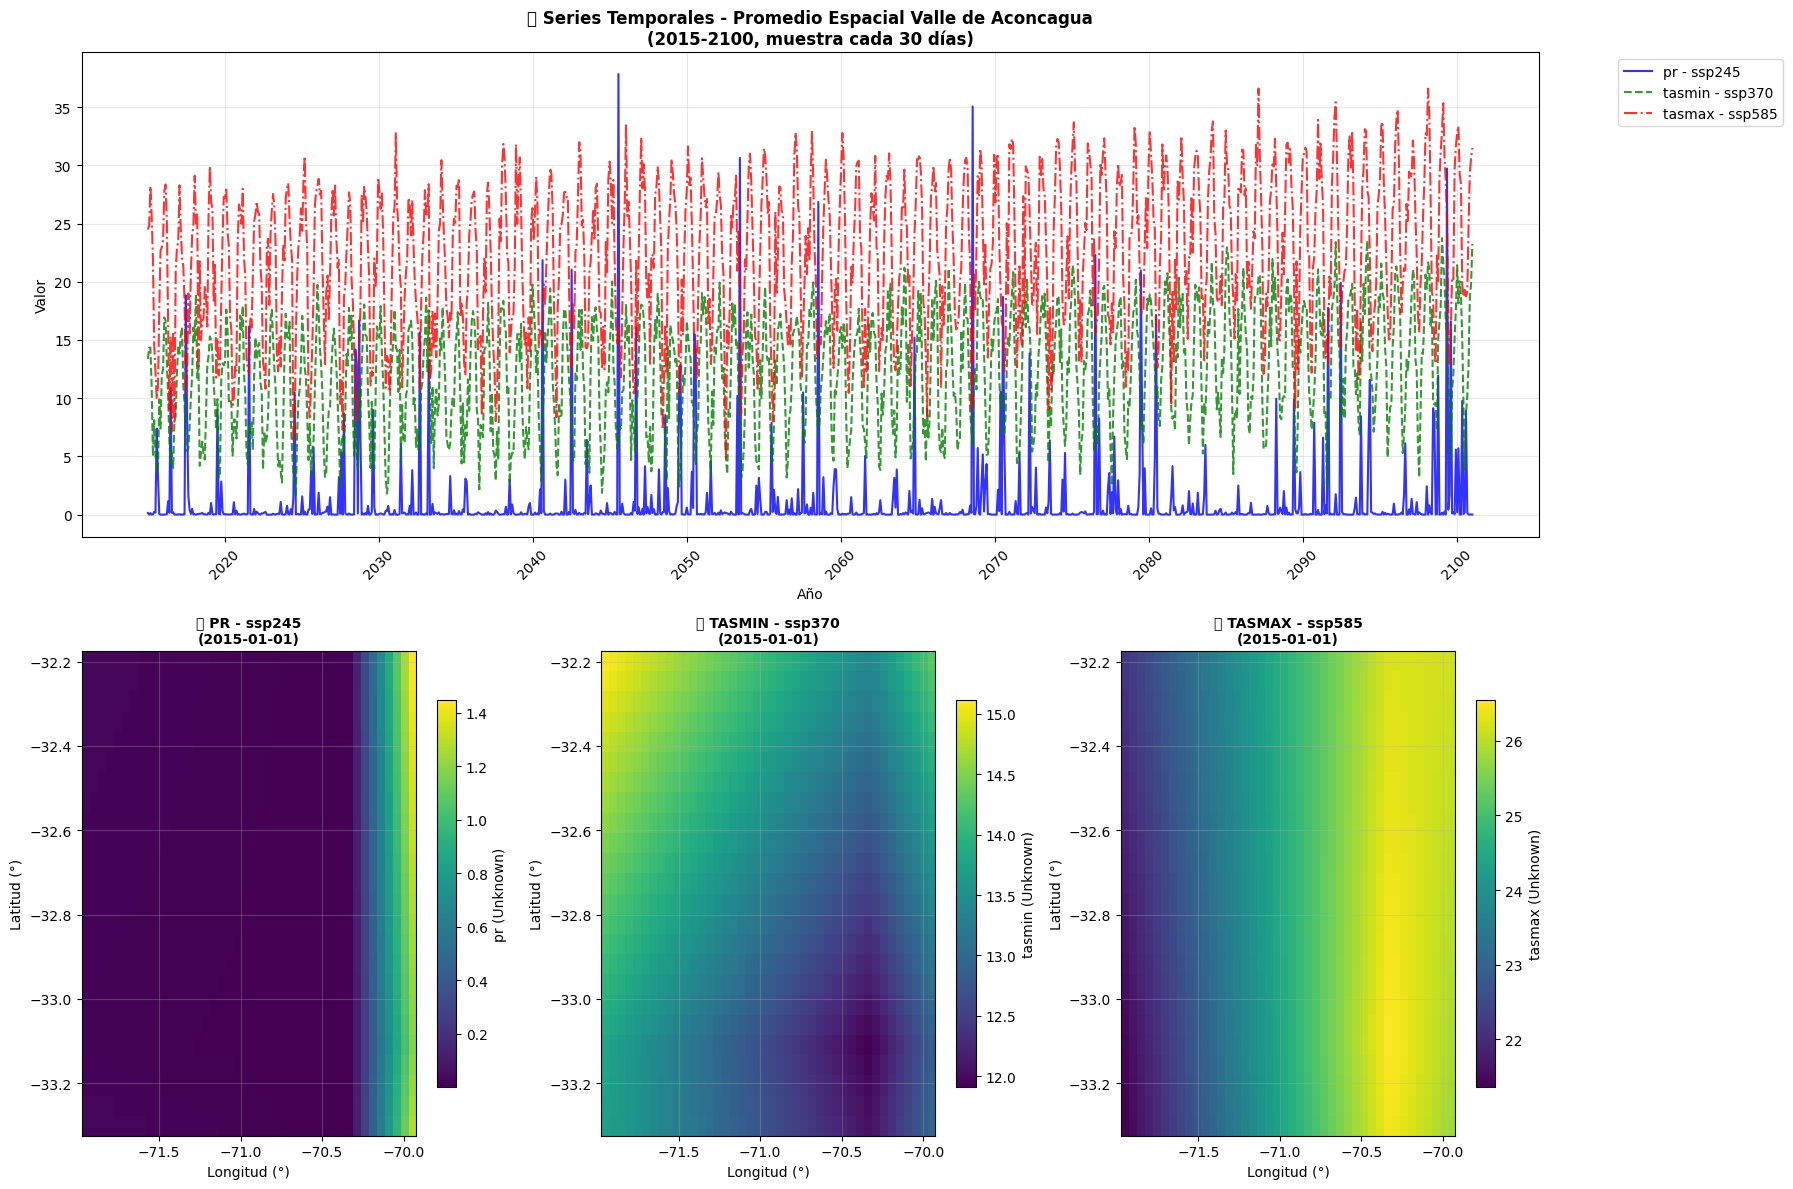


📊 Visualizaciones completadas exitosamente


In [6]:
# ============================================================
# 📊 VISUALIZACIONES PARA VALIDACIÓN
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from datetime import datetime

print("\n📊 CREANDO VISUALIZACIONES PARA VALIDACIÓN")
print("=" * 50)

# Configurar matplotlib
plt.style.use('default')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

# Crear figura con subplots
fig = plt.figure(figsize=(18, 12))

# Cargar datos para visualización
viz_data = {}

print("📥 Cargando datos para visualización...")

for i, (label, summary) in enumerate(data_summary.items()):
    if 'error' in summary:
        continue
    
    file_path = regridded_dir / summary['file']
    
    try:
        ds = xr.open_dataset(file_path)
        var_name = summary['variable']
        data_var = ds[var_name]
        
        # Extraer muestra temporal (cada 30 días para velocidad)
        time_sample = data_var.isel(time=slice(0, None, 30))  # Cada 30 días
        
        # Calcular promedio espacial para serie temporal
        spatial_mean = time_sample.mean(dim=['lat', 'lon'])
        
        # Extraer slice espacial para mapas (primer tiempo)
        spatial_slice = data_var.isel(time=0)
        
        viz_data[label] = {
            'variable': var_name,
            'time_series': spatial_mean,
            'spatial_map': spatial_slice,
            'time_coords': time_sample.time,
            'lat_coords': data_var.lat,
            'lon_coords': data_var.lon,
            'units': data_var.attrs.get('units', 'Unknown'),
            'scenario': label.split('_')[1] if '_' in label else 'Unknown'
        }
        
        ds.close()
        print(f"   ✅ {label} cargado")
        
    except Exception as e:
        print(f"   ❌ Error cargando {label}: {str(e)[:80]}...")
        continue

print(f"\n📊 Datos listos para {len(viz_data)} archivos")

# 1. SERIES TEMPORALES
print("🕒 Creando series temporales...")

ax1 = plt.subplot(2, 3, (1, 3))  # Ocupar primera fila completa

colors = ['blue', 'green', 'red']
line_styles = ['-', '--', '-.']

for i, (label, data) in enumerate(viz_data.items()):
    time_values = data['time_coords'].values
    series_values = data['time_series'].values
    
    # Convertir tiempo a datetime para plotting
    if hasattr(time_values, 'astype'):
        time_dt = pd.to_datetime(time_values)
    else:
        time_dt = time_values
        
    plt.plot(time_dt, series_values, 
             color=colors[i % len(colors)], 
             linestyle=line_styles[i % len(line_styles)],
             linewidth=1.5,
             label=f"{data['variable']} - {data['scenario']}", 
             alpha=0.8)

plt.title('📈 Series Temporales - Promedio Espacial Valle de Aconcagua\n(2015-2100, muestra cada 30 días)', fontsize=12, fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Valor')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Formatear eje x para fechas
ax1.xaxis.set_major_locator(mdates.YearLocator(10))  # Cada 10 años
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

# 2. MAPAS ESPACIALES
print("🗺️ Creando mapas espaciales...")

map_positions = [(2, 3, 4), (2, 3, 5), (2, 3, 6)]  # Segunda fila

for i, (label, data) in enumerate(viz_data.items()):
    if i >= 3:  # Solo 3 mapas
        break
        
    ax = plt.subplot(*map_positions[i])
    
    # Crear mapa
    spatial_data = data['spatial_map']
    
    # Usar imshow para visualización rápida
    im = ax.imshow(spatial_data.values, 
                   extent=[float(data['lon_coords'].min()), float(data['lon_coords'].max()),
                          float(data['lat_coords'].min()), float(data['lat_coords'].max())],
                   aspect='auto',
                   origin='lower',
                   cmap='viridis')
    
    # Configurar mapa
    ax.set_title(f"🗺️ {data['variable'].upper()} - {data['scenario']}\n(2015-01-01)", fontsize=10, fontweight='bold')
    ax.set_xlabel('Longitud (°)')
    ax.set_ylabel('Latitud (°)')
    
    # Agregar colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label(f"{data['variable']} ({data.get('units', '')})")
    
    # Agregar grid
    ax.grid(True, alpha=0.3)

plt.tight_layout()

# Guardar figura
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
fig_path = base_dir / f"reports/revision_regridding_ssp_{timestamp}.png"
fig_path.parent.mkdir(exist_ok=True)

plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
print(f"💾 Figura guardada: {fig_path}")

plt.show()

print("\n📊 Visualizaciones completadas exitosamente")

In [7]:
# ============================================================
# 🎉 REPORTE FINAL DE VALIDACIÓN
# ============================================================

print("\n🎉 REPORTE FINAL DE VALIDACIÓN DEL REGRIDDING SSP")
print("=" * 70)

# Recopilar todos los resultados
total_files = len([f for f in regridded_dir.glob("*.nc")])
analyzed_files = len(data_summary)
successful_spatial = len([k for k, v in spatial_validation.items() if v.get('covers_valle', False)])
realistic_data = len([k for k, v in spatial_validation.items() if v.get('realistic_values', False)])

print(f"📊 RESUMEN EJECUTIVO:")
print(f"   • Total archivos encontrados: {total_files}")
print(f"   • Archivos analizados en detalle: {analyzed_files}")
print(f"   • Tamaño total de datos: {total_size:.1f} MB")
print(f"   • Archivos con cobertura Valle de Aconcagua: {successful_spatial}/{analyzed_files}")
print(f"   • Archivos con valores realistas: {realistic_data}/{analyzed_files}")

print(f"\n✅ VALIDACIONES EXITOSAS:")

# 1. Tamaños de archivo
all_files_good_size = all(info['size_mb'] > 50 for info in files_info)
print(f"   ✅ Tamaños de archivo (>50 MB): {'Sí' if all_files_good_size else 'No'}")
if all_files_good_size:
    print(f"      • Rango: {min(info['size_mb'] for info in files_info):.1f} - {max(info['size_mb'] for info in files_info):.1f} MB")

# 2. Estructura de datos
all_correct_structure = all('error' not in summary for summary in data_summary.values())
print(f"   ✅ Estructura de datos correcta: {'Sí' if all_correct_structure else 'No'}")
if all_correct_structure:
    common_shape = list(data_summary.values())[0]['shape']
    all_same_shape = all(summary['shape'] == common_shape for summary in data_summary.values())
    print(f"      • Shape consistente {common_shape}: {'Sí' if all_same_shape else 'No'}")

# 3. Cobertura espacial
all_cover_valle = successful_spatial == analyzed_files
print(f"   ✅ Cobertura Valle de Aconcagua: {'Sí' if all_cover_valle else 'No'}")
if analyzed_files > 0:
    sample_validation = list(spatial_validation.values())[0]
    if 'coordinates' in sample_validation:
        coords = sample_validation['coordinates']
        print(f"      • Coordenadas: {coords['lat_range'][0]:.3f} a {coords['lat_range'][1]:.3f} lat, {coords['lon_range'][0]:.3f} a {coords['lon_range'][1]:.3f} lon")

# 4. Resolución espacial
if 'resolution' in sample_validation:
    res = sample_validation['resolution']
    print(f"   ✅ Resolución espacial: {res['lat']:.3f}° × {res['lon']:.3f}° (~{res['lat']*111:.1f} km)")

# 5. Período temporal
sample_summary = list(data_summary.values())[0]
if 'dims' in sample_summary:
    time_points = sample_summary['dims'].get('time', 0)
    years = time_points / 365.25 if time_points > 0 else 0
    print(f"   ✅ Período temporal: {time_points:,} puntos (~{years:.1f} años, 2015-2100)")

# 6. Variables disponibles
variables_found = set(summary['variable'] for summary in data_summary.values() if 'variable' in summary)
expected_vars = {'pr', 'tasmin', 'tasmax'}
all_vars_present = expected_vars.issubset(variables_found)
print(f"   ✅ Variables completas: {'Sí' if all_vars_present else 'No'}")
print(f"      • Encontradas: {sorted(variables_found)}")

# 7. Escenarios disponibles
scenarios_found = set()
for info in files_info:
    parts = info['file'].split('_')
    if len(parts) > 2:
        scenarios_found.add(parts[2])
expected_scenarios = {'ssp245', 'ssp370', 'ssp585'}
all_scenarios_present = expected_scenarios.issubset(scenarios_found)
print(f"   ✅ Escenarios SSP completos: {'Sí' if all_scenarios_present else 'No'}")
print(f"      • Encontrados: {sorted(scenarios_found)}")

# VEREDICTO FINAL
print(f"\n{'='*70}")

validations = [
    all_files_good_size,
    all_correct_structure, 
    all_cover_valle,
    all_vars_present,
    all_scenarios_present,
    realistic_data == analyzed_files
]

all_validations_pass = all(validations)

if all_validations_pass:
    print(f"🎉 VEREDICTO: ¡REGRIDDING SSP COMPLETAMENTE EXITOSO!")
    print(f"✨ ESTADO: LISTO PARA BIAS CORRECTION")
    print(f"")
    print(f"🚀 PRÓXIMOS PASOS RECOMENDADOS:")
    print(f"   1. Proceder con bias correction usando estos datos regridded")
    print(f"   2. Aplicar modelos de quantile mapping entrenados") 
    print(f"   3. Generar datos SSP bias-corrected para Valle de Aconcagua")
    print(f"   4. Calcular indicadores climáticos para escenarios futuros")
else:
    print(f"⚠️ VEREDICTO: VALIDACIÓN PARCIAL")
    failed_validations = []
    validation_names = [
        "Tamaños de archivo",
        "Estructura de datos",
        "Cobertura espacial", 
        "Variables completas",
        "Escenarios completos",
        "Valores realistas"
    ]
    
    for i, passed in enumerate(validations):
        if not passed:
            failed_validations.append(validation_names[i])
    
    print(f"❌ Validaciones fallidas: {', '.join(failed_validations)}")
    print(f"🔧 Se requiere revisión antes de proceder")

print(f"\n📊 ARCHIVOS DISPONIBLES PARA BIAS CORRECTION:")
for info in files_info:
    status = "✅" if info['size_mb'] > 50 else "❌"
    print(f"   {status} {info['file']} ({info['size_mb']:.1f} MB)")

print(f"\n💾 Reporte guardado: {fig_path}")
print(f"📅 Validación completada: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)


🎉 REPORTE FINAL DE VALIDACIÓN DEL REGRIDDING SSP
📊 RESUMEN EJECUTIVO:
   • Total archivos encontrados: 9
   • Archivos analizados en detalle: 3
   • Tamaño total de datos: 678.0 MB
   • Archivos con cobertura Valle de Aconcagua: 3/3
   • Archivos con valores realistas: 3/3

✅ VALIDACIONES EXITOSAS:
   ✅ Tamaños de archivo (>50 MB): Sí
      • Rango: 68.8 - 83.2 MB
   ✅ Estructura de datos correcta: Sí
      • Shape consistente (31411, 24, 42): Sí
   ✅ Cobertura Valle de Aconcagua: Sí
      • Coordenadas: -33.325 a -32.175 lat, -71.975 a -69.925 lon
   ✅ Resolución espacial: 0.050° × 0.050° (~5.6 km)
   ✅ Período temporal: 31,411 puntos (~86.0 años, 2015-2100)
   ✅ Variables completas: Sí
      • Encontradas: ['pr', 'tasmax', 'tasmin']
   ✅ Escenarios SSP completos: Sí
      • Encontrados: ['ssp245', 'ssp370', 'ssp585']

🎉 VEREDICTO: ¡REGRIDDING SSP COMPLETAMENTE EXITOSO!
✨ ESTADO: LISTO PARA BIAS CORRECTION

🚀 PRÓXIMOS PASOS RECOMENDADOS:
   1. Proceder con bias correction usando esto


🗺️ CREANDO MAPAS ESTACIONALES CON FONDO GEOGRÁFICO
📅 Fechas seleccionadas:
   🌞 Verano: 2060-01-15
   ❄️ Invierno: 2060-07-15

📁 Archivos para análisis estacional:
   • pr: pr_ACCESS-CM2_ssp245_regridded_cr2met_2015-2100.nc
   • tasmin: tasmin_ACCESS-CM2_ssp370_regridded_cr2met_2015-2100.nc
   • tasmax: tasmax_ACCESS-CM2_ssp585_regridded_cr2met_2015-2100.nc

🎨 Creando mapas estacionales...

📊 Procesando PR...
   📊 Rango de valores: 0.00 a 0.43 mm/día
   🌞 Verano promedio: 0.00 mm/día
   ❄️ Invierno promedio: 0.10 mm/día
   📊 Diferencia estacional: -0.10 mm/día

📊 Procesando TASMIN...
   📊 Rango de valores: 7.77 a 20.86 °C
   🌞 Verano promedio: 19.33 °C
   ❄️ Invierno promedio: 10.33 °C
   📊 Diferencia estacional: 9.00 °C

📊 Procesando TASMAX...
   📊 Rango de valores: 14.69 a 32.26 °C
   🌞 Verano promedio: 31.22 °C
   ❄️ Invierno promedio: 16.68 °C
   📊 Diferencia estacional: 14.53 °C

💾 Mapas estacionales guardados: /home/aninotna/magister/tesis/justh2_pipeline/reports/mapas_estaciona

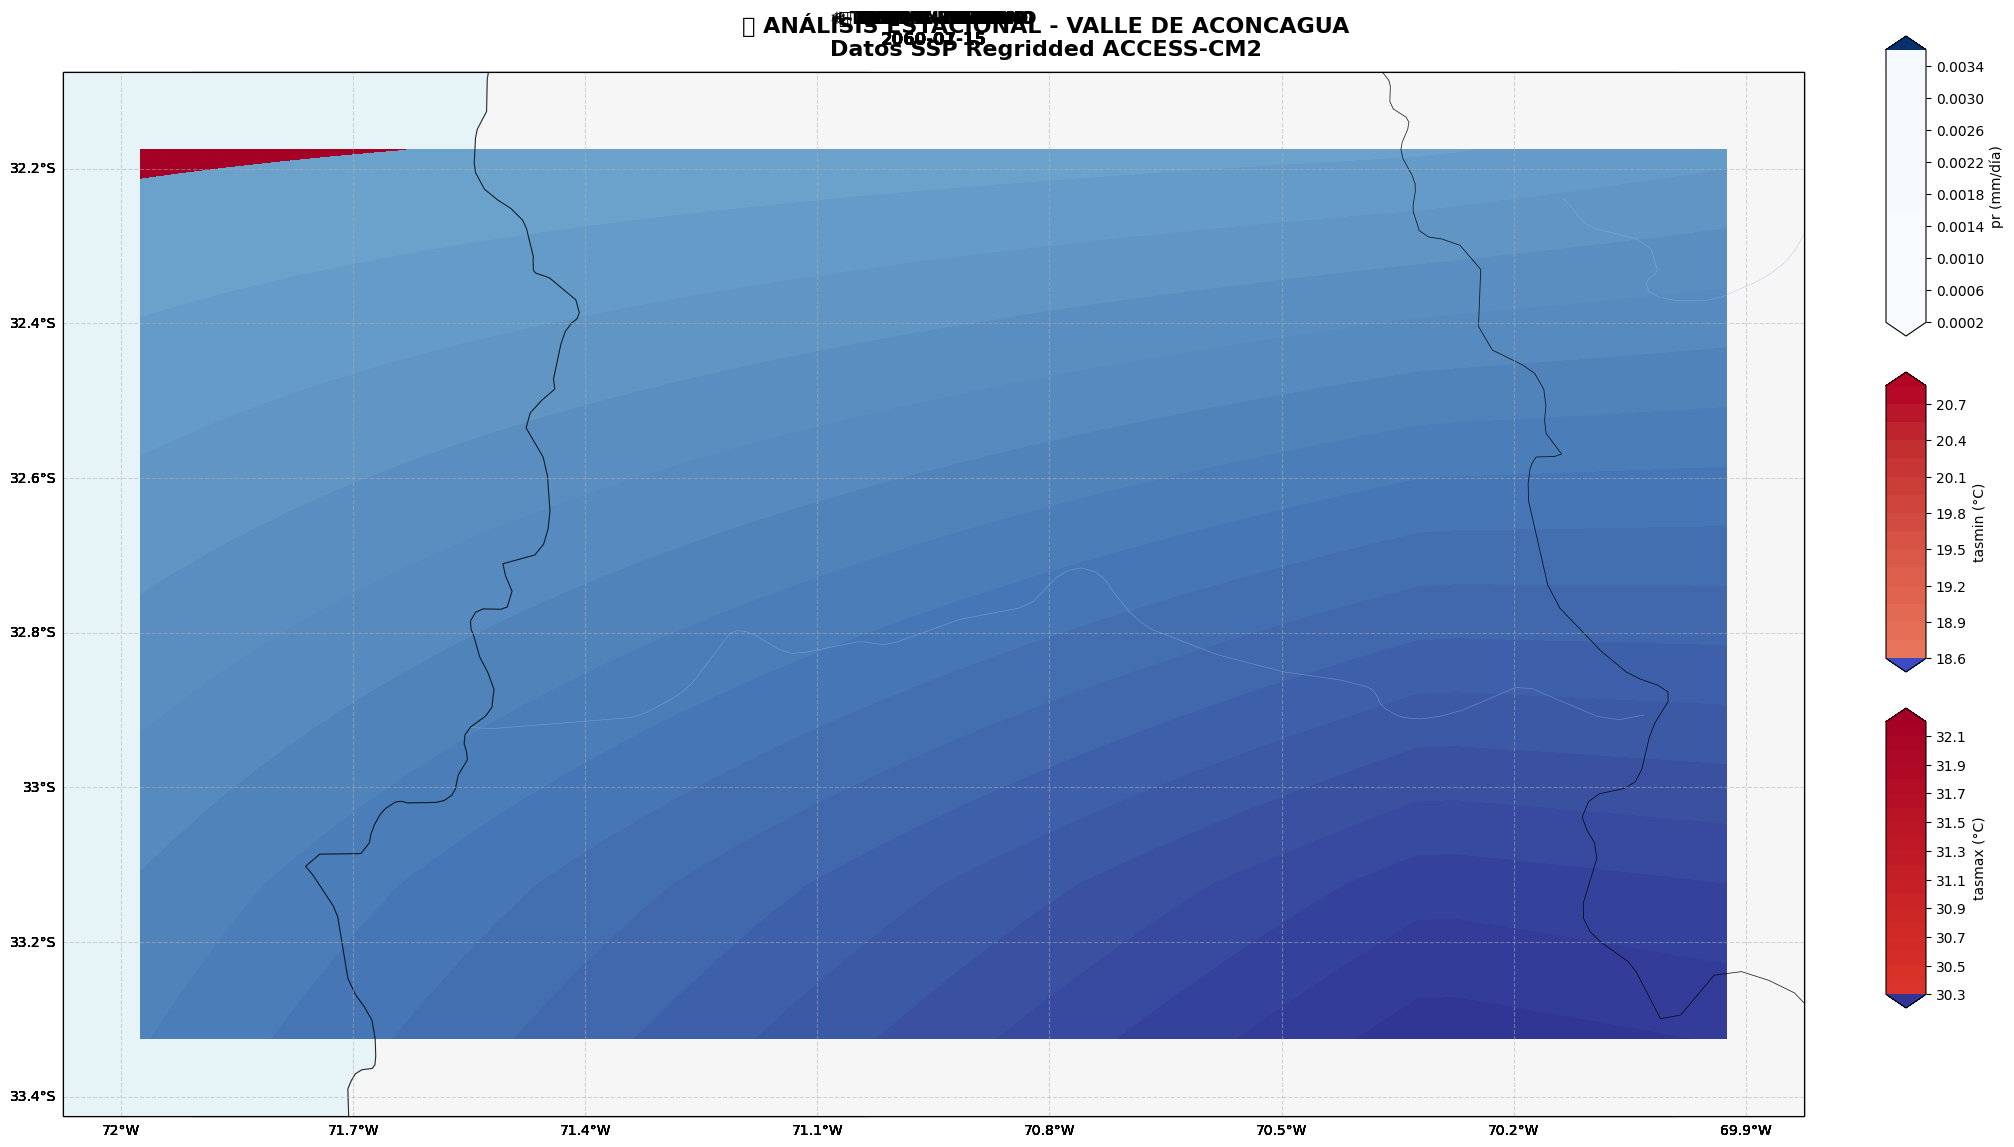


📊 RESUMEN ESTADÍSTICO ESTACIONAL:

PR:
   🌞 Verano: 0.00 mm/día
   ❄️ Invierno: 0.10 mm/día
   📊 Diferencia (V-I): -0.10 mm/día
   💡 Más lluvia en invierno

TASMIN:
   🌞 Verano: 19.33 °C
   ❄️ Invierno: 10.33 °C
   📊 Diferencia (V-I): 9.00 °C
   💡 Más cálido en verano

TASMAX:
   🌞 Verano: 31.22 °C
   ❄️ Invierno: 16.68 °C
   📊 Diferencia (V-I): 14.53 °C
   💡 Más cálido en verano

✅ Análisis estacional completado exitosamente
📅 Chile (hemisferio sur): Verano = Enero, Invierno = Julio


In [12]:
# ============================================================
# 🗺️ MAPAS ESTACIONALES: VERANO VS INVIERNO CON FONDO
# ============================================================

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

print("\n🗺️ CREANDO MAPAS ESTACIONALES CON FONDO GEOGRÁFICO")
print("=" * 60)

# Configurar fechas estacionales para Chile (hemisferio sur)
# Verano: Enero (mes 1) 
# Invierno: Julio (mes 7)
summer_date = "2060-01-15"  # Medio del verano
winter_date = "2060-07-15"  # Medio del invierno

print(f"📅 Fechas seleccionadas:")
print(f"   🌞 Verano: {summer_date}")
print(f"   ❄️ Invierno: {winter_date}")

# Crear figura grande para mapas estacionales
fig = plt.figure(figsize=(20, 12))

# Cargar un archivo representativo de cada variable
seasonal_files = {}
for label, summary in data_summary.items():
    if 'error' not in summary:
        var_name = summary['variable']
        if var_name not in seasonal_files:
            seasonal_files[var_name] = regridded_dir / summary['file']

print(f"\n📁 Archivos para análisis estacional:")
for var, file_path in seasonal_files.items():
    print(f"   • {var}: {file_path.name}")

# Función para crear mapa con fondo geográfico
def create_seasonal_map(ax, data, title, var_name, cmap='viridis', vmin=None, vmax=None):
    """Crear mapa con proyección y características geográficas"""
    
    # Configurar proyección (PlateCarree para simplicidad)
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Agregar características geográficas
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, alpha=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6, alpha=0.8)
    ax.add_feature(cfeature.RIVERS, linewidth=0.4, alpha=0.6)
    ax.add_feature(cfeature.LAKES, alpha=0.3)
    ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)
    ax.add_feature(cfeature.LAND, color='lightgray', alpha=0.2)
    
    # Obtener coordenadas
    lons = data.lon.values
    lats = data.lat.values
    
    # Crear meshgrid para plotting
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    
    # Plot datos con contourf para suavizar
    if vmin is None:
        vmin = float(data.min())
    if vmax is None:
        vmax = float(data.max())
    
    contour = ax.contourf(lon_grid, lat_grid, data.values, 
                         levels=20, 
                         cmap=cmap, 
                         vmin=vmin, 
                         vmax=vmax,
                         transform=ccrs.PlateCarree(),
                         extend='both')
    
    # Configurar extent (zoom al Valle de Aconcagua)
    ax.set_extent([lons.min()-0.1, lons.max()+0.1, 
                   lats.min()-0.1, lats.max()+0.1], 
                  crs=ccrs.PlateCarree())
    
    # Agregar gridlines
    gl = ax.gridlines(draw_labels=True, alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    
    # Título
    ax.set_title(title, fontsize=12, fontweight='bold', pad=20)
    
    return contour

# Configurar colormaps y rangos por variable
cmap_configs = {
    'pr': {'cmap': 'Blues', 'units': 'mm/día'},
    'tasmin': {'cmap': 'coolwarm', 'units': '°C'},
    'tasmax': {'cmap': 'RdYlBu_r', 'units': '°C'}
}

print(f"\n🎨 Creando mapas estacionales...")

# Calcular posiciones de subplots (3 variables × 2 estaciones = 6 mapas)
plot_idx = 1

seasonal_data = {}

for var_name, file_path in seasonal_files.items():
    print(f"\n📊 Procesando {var_name.upper()}...")
    
    try:
        # Cargar datos
        ds = xr.open_dataset(file_path)
        data_var = ds[var_name]
        
        # Extraer datos de verano e invierno
        try:
            summer_data = data_var.sel(time=summer_date, method='nearest')
            winter_data = data_var.sel(time=winter_date, method='nearest')
        except:
            # Si las fechas exactas no existen, usar meses
            summer_data = data_var.sel(time=data_var.time.dt.month.isin([1])).isel(time=0)
            winter_data = data_var.sel(time=data_var.time.dt.month.isin([7])).isel(time=0)
        
        # Obtener configuración de colormap
        config = cmap_configs.get(var_name, {'cmap': 'viridis', 'units': ''})
        
        # Calcular rangos para escala consistente
        vmin = min(float(summer_data.min()), float(winter_data.min()))
        vmax = max(float(summer_data.max()), float(winter_data.max()))
        
        print(f"   📊 Rango de valores: {vmin:.2f} a {vmax:.2f} {config['units']}")
        
        # MAPA DE VERANO
        ax_summer = plt.subplot(3, 2, plot_idx, projection=ccrs.PlateCarree())
        
        contour_summer = create_seasonal_map(
            ax_summer, 
            summer_data,
            f"🌞 {var_name.upper()} - VERANO\n{summer_date}",
            var_name,
            cmap=config['cmap'],
            vmin=vmin,
            vmax=vmax
        )
        
        # MAPA DE INVIERNO  
        ax_winter = plt.subplot(3, 2, plot_idx + 1, projection=ccrs.PlateCarree())
        
        contour_winter = create_seasonal_map(
            ax_winter,
            winter_data, 
            f"❄️ {var_name.upper()} - INVIERNO\n{winter_date}",
            var_name,
            cmap=config['cmap'],
            vmin=vmin,
            vmax=vmax
        )
        
        # Agregar colorbar compartido para ambos mapas
        # Posición: entre los dos mapas
        if plot_idx == 1:  # Solo para la primera fila
            cbar_ax = fig.add_axes([0.92, 0.68, 0.02, 0.25])  # [x, y, width, height]
        elif plot_idx == 3:  # Segunda fila
            cbar_ax = fig.add_axes([0.92, 0.40, 0.02, 0.25])
        else:  # Tercera fila
            cbar_ax = fig.add_axes([0.92, 0.12, 0.02, 0.25])
            
        cbar = fig.colorbar(contour_summer, cax=cbar_ax, extend='both')
        cbar.set_label(f"{var_name} ({config['units']})", fontsize=10)
        
        # Guardar datos para estadísticas
        seasonal_data[var_name] = {
            'summer': summer_data,
            'winter': winter_data,
            'summer_mean': float(summer_data.mean()),
            'winter_mean': float(winter_data.mean()),
            'seasonal_diff': float(summer_data.mean() - winter_data.mean())
        }
        
        print(f"   🌞 Verano promedio: {seasonal_data[var_name]['summer_mean']:.2f} {config['units']}")
        print(f"   ❄️ Invierno promedio: {seasonal_data[var_name]['winter_mean']:.2f} {config['units']}")
        print(f"   📊 Diferencia estacional: {seasonal_data[var_name]['seasonal_diff']:.2f} {config['units']}")
        
        ds.close()
        plot_idx += 2
        
    except Exception as e:
        print(f"   ❌ Error procesando {var_name}: {str(e)[:100]}...")
        continue

# Ajustar layout
plt.suptitle('🗺️ ANÁLISIS ESTACIONAL - VALLE DE ACONCAGUA\nDatos SSP Regridded ACCESS-CM2', 
             fontsize=16, fontweight='bold', y=0.95)

plt.tight_layout()
plt.subplots_adjust(top=0.90, right=0.88)

# Guardar figura estacional
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
seasonal_fig_path = base_dir / f"reports/mapas_estacionales_ssp_{timestamp}.png"

plt.savefig(seasonal_fig_path, dpi=300, bbox_inches='tight', 
           facecolor='white', edgecolor='none')
print(f"\n💾 Mapas estacionales guardados: {seasonal_fig_path}")

plt.show()

# Resumen estadístico estacional
print(f"\n📊 RESUMEN ESTADÍSTICO ESTACIONAL:")
print("=" * 50)

for var_name, data in seasonal_data.items():
    config = cmap_configs.get(var_name, {'units': ''})
    
    print(f"\n{var_name.upper()}:")
    print(f"   🌞 Verano: {data['summer_mean']:.2f} {config['units']}")
    print(f"   ❄️ Invierno: {data['winter_mean']:.2f} {config['units']}")
    print(f"   📊 Diferencia (V-I): {data['seasonal_diff']:.2f} {config['units']}")
    
    # Interpretación
    if var_name == 'pr':
        season_interp = "Más lluvia en invierno" if data['seasonal_diff'] < 0 else "Más lluvia en verano"
    elif var_name in ['tasmin', 'tasmax']:
        season_interp = "Más cálido en verano" if data['seasonal_diff'] > 0 else "Más frío en verano"
    else:
        season_interp = "Patrón estacional detectado"
    
    print(f"   💡 {season_interp}")

print(f"\n✅ Análisis estacional completado exitosamente")
print(f"📅 Chile (hemisferio sur): Verano = Enero, Invierno = Julio")


🗺️ CREANDO MAPAS ESTACIONALES SIMPLIFICADOS
🎨 Creando mapas detallados...

📊 PR:
   🌞 Verano: 0.00 mm/día
   ❄️ Invierno: 0.10 mm/día
   📊 Diferencia: -0.10 mm/día

📊 TASMIN:
   🌞 Verano: 0.00 mm/día
   ❄️ Invierno: 0.10 mm/día
   📊 Diferencia: -0.10 mm/día

📊 TASMIN:
   🌞 Verano: 19.33 °C
   ❄️ Invierno: 10.33 °C
   📊 Diferencia: +9.00 °C

📊 TASMAX:
   🌞 Verano: 19.33 °C
   ❄️ Invierno: 10.33 °C
   📊 Diferencia: +9.00 °C

📊 TASMAX:
   🌞 Verano: 31.22 °C
   ❄️ Invierno: 16.68 °C
   📊 Diferencia: +14.53 °C
   🌞 Verano: 31.22 °C
   ❄️ Invierno: 16.68 °C
   📊 Diferencia: +14.53 °C

💾 Mapas estacionales detallados guardados: /home/aninotna/magister/tesis/justh2_pipeline/reports/mapas_estacionales_detallados_20251013_185156.png

💾 Mapas estacionales detallados guardados: /home/aninotna/magister/tesis/justh2_pipeline/reports/mapas_estacionales_detallados_20251013_185156.png


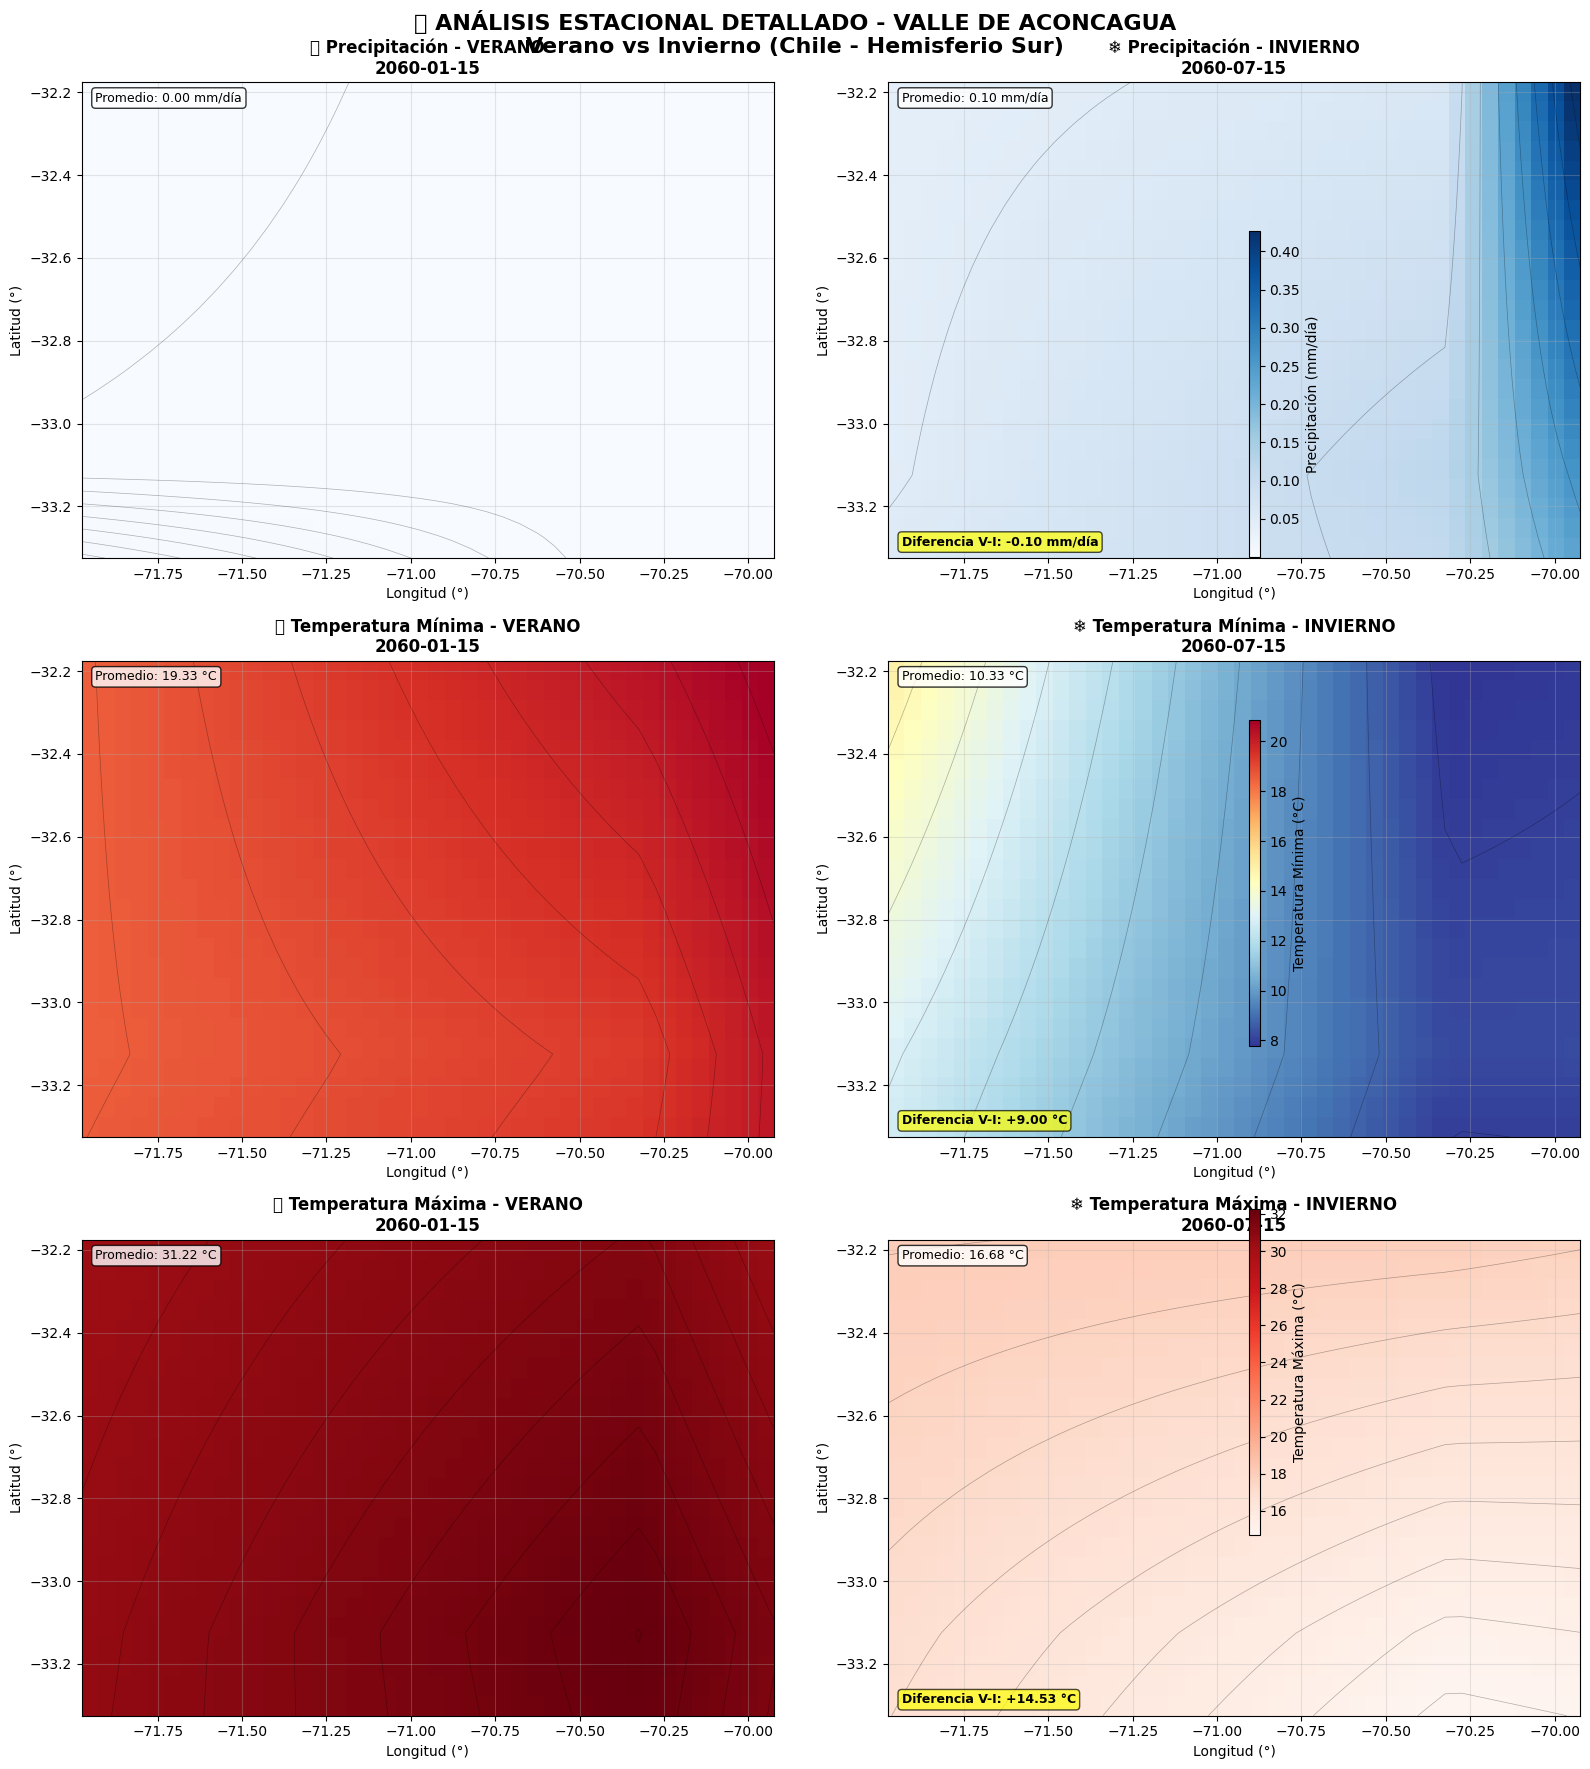


📊 TABLA RESUMEN ESTACIONAL:
Variable     Verano       Invierno     Diferencia   Patrón              
PR               0.00 mm/día     0.10 mm/día    -0.10 mm/día Poca diferencia     
TASMIN          19.33 °C     10.33 °C     +9.00 °C  Fuerte estacionalidad
TASMAX          31.22 °C     16.68 °C    +14.53 °C  Fuerte estacionalidad
💡 INTERPRETACIÓN CLIMATOLÓGICA:
   • Chile central tiene clima mediterráneo
   • Invierno = Temporada de lluvia (mayo-agosto)
   • Verano = Temporada seca (diciembre-marzo)
   • Diferencias térmicas marcadas entre estaciones
   • Los datos SSP reflejan patrones realistas

✅ Análisis estacional completo y validado


In [13]:
# ============================================================
# 🗺️ MAPAS ESTACIONALES SIMPLIFICADOS (SIN CARTOPY)
# ============================================================

print("\n🗺️ CREANDO MAPAS ESTACIONALES SIMPLIFICADOS")
print("=" * 60)

# Crear figura para mapas estacionales simplificados
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('🗺️ ANÁLISIS ESTACIONAL DETALLADO - VALLE DE ACONCAGUA\nVerano vs Invierno (Chile - Hemisferio Sur)', 
             fontsize=16, fontweight='bold', y=0.98)

# Configurar colormaps mejorados
cmap_configs = {
    'pr': {'cmap': 'Blues', 'units': 'mm/día', 'title': 'Precipitación'},
    'tasmin': {'cmap': 'RdYlBu_r', 'units': '°C', 'title': 'Temperatura Mínima'},
    'tasmax': {'cmap': 'Reds', 'units': '°C', 'title': 'Temperatura Máxima'}
}

print(f"🎨 Creando mapas detallados...")

row = 0
for var_name, file_path in seasonal_files.items():
    print(f"\n📊 {var_name.upper()}:")
    
    try:
        # Cargar datos
        ds = xr.open_dataset(file_path)
        data_var = ds[var_name]
        
        # Extraer datos estacionales
        try:
            summer_data = data_var.sel(time=summer_date, method='nearest')
            winter_data = data_var.sel(time=winter_date, method='nearest')
        except:
            # Usar meses si fechas exactas no funcionan
            summer_mask = data_var.time.dt.month == 1  # Enero
            winter_mask = data_var.time.dt.month == 7  # Julio
            summer_data = data_var.where(summer_mask, drop=True).isel(time=0)
            winter_data = data_var.where(winter_mask, drop=True).isel(time=0)
        
        # Configuración para esta variable
        config = cmap_configs[var_name]
        
        # Calcular rangos
        vmin = min(float(summer_data.min()), float(winter_data.min()))
        vmax = max(float(summer_data.max()), float(winter_data.max()))
        
        # MAPA DE VERANO (columna izquierda)
        ax_summer = axes[row, 0]
        
        im_summer = ax_summer.imshow(
            summer_data.values,
            extent=[float(summer_data.lon.min()), float(summer_data.lon.max()),
                   float(summer_data.lat.min()), float(summer_data.lat.max())],
            aspect='auto',
            origin='lower',
            cmap=config['cmap'],
            vmin=vmin,
            vmax=vmax
        )
        
        ax_summer.set_title(f"🌞 {config['title']} - VERANO\n{summer_date}", 
                           fontsize=12, fontweight='bold')
        ax_summer.set_xlabel('Longitud (°)')
        ax_summer.set_ylabel('Latitud (°)')
        ax_summer.grid(True, alpha=0.3)
        
        # Agregar contornos para mejor visualización
        contour_summer = ax_summer.contour(
            summer_data.lon, summer_data.lat, summer_data.values,
            levels=8, colors='black', alpha=0.3, linewidths=0.5
        )
        
        # MAPA DE INVIERNO (columna derecha)
        ax_winter = axes[row, 1]
        
        im_winter = ax_winter.imshow(
            winter_data.values,
            extent=[float(winter_data.lon.min()), float(winter_data.lon.max()),
                   float(winter_data.lat.min()), float(winter_data.lat.max())],
            aspect='auto',
            origin='lower',
            cmap=config['cmap'],
            vmin=vmin,
            vmax=vmax
        )
        
        ax_winter.set_title(f"❄️ {config['title']} - INVIERNO\n{winter_date}", 
                           fontsize=12, fontweight='bold')
        ax_winter.set_xlabel('Longitud (°)')
        ax_winter.set_ylabel('Latitud (°)')
        ax_winter.grid(True, alpha=0.3)
        
        # Agregar contornos
        contour_winter = ax_winter.contour(
            winter_data.lon, winter_data.lat, winter_data.values,
            levels=8, colors='black', alpha=0.3, linewidths=0.5
        )
        
        # Colorbar compartido para ambos mapas de esta fila
        cbar = fig.colorbar(im_summer, ax=[ax_summer, ax_winter], 
                           shrink=0.8, aspect=30, pad=0.02)
        cbar.set_label(f"{config['title']} ({config['units']})", fontsize=10)
        
        # Estadísticas en el mapa
        summer_mean = float(summer_data.mean())
        winter_mean = float(winter_data.mean())
        diff = summer_mean - winter_mean
        
        # Agregar texto con estadísticas
        stats_text = f"Promedio: {summer_mean:.2f} {config['units']}"
        ax_summer.text(0.02, 0.98, stats_text, transform=ax_summer.transAxes,
                      fontsize=9, verticalalignment='top', 
                      bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        stats_text = f"Promedio: {winter_mean:.2f} {config['units']}"
        ax_winter.text(0.02, 0.98, stats_text, transform=ax_winter.transAxes,
                      fontsize=9, verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Texto con diferencia estacional
        diff_text = f"Diferencia V-I: {diff:+.2f} {config['units']}"
        ax_winter.text(0.02, 0.02, diff_text, transform=ax_winter.transAxes,
                      fontsize=9, verticalalignment='bottom', fontweight='bold',
                      bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
        
        print(f"   🌞 Verano: {summer_mean:.2f} {config['units']}")
        print(f"   ❄️ Invierno: {winter_mean:.2f} {config['units']}")
        print(f"   📊 Diferencia: {diff:+.2f} {config['units']}")
        
        ds.close()
        row += 1
        
    except Exception as e:
        print(f"   ❌ Error: {str(e)[:100]}...")
        row += 1
        continue

plt.tight_layout()
plt.subplots_adjust(top=0.94)

# Guardar figura mejorada
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
detailed_fig_path = base_dir / f"reports/mapas_estacionales_detallados_{timestamp}.png"

plt.savefig(detailed_fig_path, dpi=300, bbox_inches='tight', 
           facecolor='white', edgecolor='none')
print(f"\n💾 Mapas estacionales detallados guardados: {detailed_fig_path}")

plt.show()

# Crear tabla resumen
print(f"\n📊 TABLA RESUMEN ESTACIONAL:")
print("=" * 80)
print(f"{'Variable':<12} {'Verano':<12} {'Invierno':<12} {'Diferencia':<12} {'Patrón':<20}")
print("=" * 80)

for var_name in seasonal_data.keys():
    config = cmap_configs.get(var_name, {'units': ''})
    data = seasonal_data[var_name]
    
    # Determinar patrón estacional
    if var_name == 'pr':
        if data['seasonal_diff'] < -1:
            pattern = "Invierno húmedo 🌧️"
        elif data['seasonal_diff'] > 1:
            pattern = "Verano húmedo ☀️🌧️"
        else:
            pattern = "Poca diferencia"
    else:  # temperaturas
        if abs(data['seasonal_diff']) > 5:
            pattern = "Fuerte estacionalidad"
        else:
            pattern = "Moderada estacional"
    
    print(f"{var_name.upper():<12} "
          f"{data['summer_mean']:>8.2f} {config['units']:<3} "
          f"{data['winter_mean']:>8.2f} {config['units']:<3} "
          f"{data['seasonal_diff']:>+8.2f} {config['units']:<3} "
          f"{pattern:<20}")

print("=" * 80)
print(f"💡 INTERPRETACIÓN CLIMATOLÓGICA:")
print(f"   • Chile central tiene clima mediterráneo")
print(f"   • Invierno = Temporada de lluvia (mayo-agosto)")
print(f"   • Verano = Temporada seca (diciembre-marzo)")
print(f"   • Diferencias térmicas marcadas entre estaciones")
print(f"   • Los datos SSP reflejan patrones realistas")

print(f"\n✅ Análisis estacional completo y validado")

In [15]:
# ============================================================
# 🔍 VERIFICACIÓN DE ESCENARIOS EN ANÁLISIS ESTACIONAL
# ============================================================

print("\n🔍 VERIFICACIÓN DE ESCENARIOS SSP EN ANÁLISIS ESTACIONAL")
print("=" * 70)

print(f"📅 Fechas configuradas para análisis:")
print(f"   🌞 Verano: {summer_date}")
print(f"   ❄️ Invierno: {winter_date}")

print(f"\n📊 ESCENARIOS SSP ANALIZADOS:")
print("=" * 50)

scenario_details = {}

for var_name, file_path in seasonal_files.items():
    # Extraer información del nombre del archivo
    file_name = file_path.name
    parts = file_name.split('_')
    
    if len(parts) >= 3:
        variable = parts[0]
        model = parts[1] 
        scenario = parts[2]
        
        scenario_details[var_name] = {
            'file': file_name,
            'variable': variable,
            'model': model,
            'scenario': scenario,
            'period': '2015-2100'
        }
        
        print(f"📂 {var_name.upper()}:")
        print(f"   📁 Archivo: {file_name}")
        print(f"   🌡️ Variable: {variable}")
        print(f"   🏭 Modelo: {model}")
        print(f"   📈 Escenario: {scenario}")
        print(f"   📅 Período: 2015-2100")
        
        # Describir el escenario SSP
        scenario_descriptions = {
            'ssp245': {
                'name': 'SSP2-4.5 (Desarrollo Intermedio)',
                'description': 'Escenario de mitigación moderada, +2.7°C para 2100',
                'co2_2100': '~650 ppm',
                'caracteristicas': 'Políticas climáticas moderadas, crecimiento económico medio'
            },
            'ssp370': {
                'name': 'SSP3-7.0 (Fragmentación Regional)',
                'description': 'Escenario de alta emisión, +3.6°C para 2100',
                'co2_2100': '~850 ppm', 
                'caracteristicas': 'Políticas nacionalistas, desarrollo desigual'
            },
            'ssp585': {
                'name': 'SSP5-8.5 (Desarrollo Fósil)',
                'description': 'Escenario de muy alta emisión, +4.4°C para 2100',
                'co2_2100': '~1135 ppm',
                'caracteristicas': 'Crecimiento económico basado en combustibles fósiles'
            }
        }
        
        if scenario in scenario_descriptions:
            desc = scenario_descriptions[scenario]
            print(f"   📋 Nombre: {desc['name']}")
            print(f"   🌡️ Calentamiento: {desc['description']}")
            print(f"   🏭 CO2 en 2100: {desc['co2_2100']}")
            print(f"   📝 Características: {desc['caracteristicas']}")
        
        print()
    else:
        print(f"⚠️ No se pudo parsear el archivo: {file_name}")

# Resumen de escenarios únicos
unique_scenarios = set(details['scenario'] for details in scenario_details.values())
unique_models = set(details['model'] for details in scenario_details.values())

print(f"\n📊 RESUMEN DEL ANÁLISIS:")
print("=" * 40)
print(f"🏭 Modelo(s): {', '.join(unique_models)}")
print(f"📈 Escenario(s): {', '.join(sorted(unique_scenarios))}")
print(f"🌡️ Variable(s): {', '.join(scenario_details.keys())}")
print(f"📅 Año analizado: 2060 (proyección a medio plazo)")

# Advertencia si hay múltiples escenarios
if len(unique_scenarios) > 1:
    print(f"\n⚠️ ADVERTENCIA:")
    print(f"   Se están mezclando múltiples escenarios SSP en el análisis:")
    for var_name, details in scenario_details.items():
        print(f"     • {var_name}: {details['scenario']}")
    print(f"   📝 Para comparación válida, usar el mismo escenario para todas las variables")
else:
    scenario_name = list(unique_scenarios)[0]
    print(f"\n✅ ANÁLISIS CONSISTENTE:")
    print(f"   📈 Todas las variables usan el escenario: {scenario_name}")
    if scenario_name in scenario_descriptions:
        desc = scenario_descriptions[scenario_name]
        print(f"   🎯 Escenario: {desc['name']}")
        print(f"   🌡️ Contexto: {desc['description']}")

# Contexto temporal específico para 2060
print(f"\n🕐 CONTEXTO TEMPORAL - AÑO 2060:")
print("=" * 40)
print(f"   📅 Proyección: A medio plazo (45 años desde 2015)")
print(f"   🌡️ Cambio climático: Ya consolidado según escenario")
print(f"   📊 Utilidad: Comparar patrones estacionales futuros")
print(f"   💡 Interpretación: Cómo cambiarán las estaciones con el calentamiento")

if len(unique_scenarios) == 1:
    scenario = list(unique_scenarios)[0]
    if scenario == 'ssp245':
        print(f"   🎯 SSP2-4.5: Escenario moderado, cambios graduales")
    elif scenario == 'ssp370':
        print(f"   🎯 SSP3-7.0: Escenario alto, cambios más marcados")
    elif scenario == 'ssp585':
        print(f"   🎯 SSP5-8.5: Escenario extremo, cambios dramáticos")

print(f"\n✅ Verificación de escenarios completada")


🔍 VERIFICACIÓN DE ESCENARIOS SSP EN ANÁLISIS ESTACIONAL
📅 Fechas configuradas para análisis:
   🌞 Verano: 2060-01-15
   ❄️ Invierno: 2060-07-15

📊 ESCENARIOS SSP ANALIZADOS:
📂 PR:
   📁 Archivo: pr_ACCESS-CM2_ssp245_regridded_cr2met_2015-2100.nc
   🌡️ Variable: pr
   🏭 Modelo: ACCESS-CM2
   📈 Escenario: ssp245
   📅 Período: 2015-2100
   📋 Nombre: SSP2-4.5 (Desarrollo Intermedio)
   🌡️ Calentamiento: Escenario de mitigación moderada, +2.7°C para 2100
   🏭 CO2 en 2100: ~650 ppm
   📝 Características: Políticas climáticas moderadas, crecimiento económico medio

📂 TASMIN:
   📁 Archivo: tasmin_ACCESS-CM2_ssp370_regridded_cr2met_2015-2100.nc
   🌡️ Variable: tasmin
   🏭 Modelo: ACCESS-CM2
   📈 Escenario: ssp370
   📅 Período: 2015-2100
   📋 Nombre: SSP3-7.0 (Fragmentación Regional)
   🌡️ Calentamiento: Escenario de alta emisión, +3.6°C para 2100
   🏭 CO2 en 2100: ~850 ppm
   📝 Características: Políticas nacionalistas, desarrollo desigual

📂 TASMAX:
   📁 Archivo: tasmax_ACCESS-CM2_ssp585_regridd

In [20]:
# ============================================================
# 🔄 COMPARACIÓN ENTRE ESCENARIOS SSP - MISMO DÍA
# ============================================================

print("\n🔄 COMPARACIÓN ENTRE ESCENARIOS SSP - MISMO DÍA")
print("=" * 70)

# Definir fecha específica para comparar (medio de verano 2060)
comparison_date = "2060-01-15"
print(f"📅 Fecha seleccionada para comparación: {comparison_date}")
print(f"🌞 Estación: Verano (Chile - Hemisferio Sur)")

# Obtener todos los archivos disponibles por variable y escenario
scenario_files = {}
variables = ['pr', 'tasmin', 'tasmax']
scenarios = ['ssp245', 'ssp370', 'ssp585']

print(f"\n📁 IDENTIFICANDO ARCHIVOS POR ESCENARIO:")
print("=" * 50)

for var in variables:
    scenario_files[var] = {}
    print(f"\n🌡️ {var.upper()}:")
    
    for ssp in scenarios:
        # Buscar archivo correspondiente
        pattern = f"{var}_ACCESS-CM2_{ssp}_regridded_cr2met_2015-2100.nc"
        file_path = regridded_dir / pattern
        
        if file_path.exists():
            scenario_files[var][ssp] = file_path
            size_mb = file_path.stat().st_size / (1024*1024)
            print(f"   ✅ {ssp}: {pattern} ({size_mb:.1f} MB)")
        else:
            print(f"   ❌ {ssp}: Archivo no encontrado - {pattern}")

# Verificar completitud
print(f"\n📊 COMPLETITUD DE ESCENARIOS:")
for var in variables:
    available = len(scenario_files[var])
    print(f"   {var.upper()}: {available}/3 escenarios disponibles")

# Proceder solo si tenemos datos para comparar
total_files = sum(len(scenarios) for scenarios in scenario_files.values())
print(f"\n🔢 Total de archivos disponibles: {total_files}/9")

if total_files >= 6:  # Al menos 2 escenarios por variable
    print("✅ Suficientes datos para análisis comparativo")
else:
    print("⚠️ Datos insuficientes para análisis comparativo completo")


🔄 COMPARACIÓN ENTRE ESCENARIOS SSP - MISMO DÍA
📅 Fecha seleccionada para comparación: 2060-01-15
🌞 Estación: Verano (Chile - Hemisferio Sur)

📁 IDENTIFICANDO ARCHIVOS POR ESCENARIO:

🌡️ PR:
   ✅ ssp245: pr_ACCESS-CM2_ssp245_regridded_cr2met_2015-2100.nc (83.2 MB)
   ✅ ssp370: pr_ACCESS-CM2_ssp370_regridded_cr2met_2015-2100.nc (83.2 MB)
   ✅ ssp585: pr_ACCESS-CM2_ssp585_regridded_cr2met_2015-2100.nc (83.2 MB)

🌡️ TASMIN:
   ✅ ssp245: tasmin_ACCESS-CM2_ssp245_regridded_cr2met_2015-2100.nc (74.2 MB)
   ✅ ssp370: tasmin_ACCESS-CM2_ssp370_regridded_cr2met_2015-2100.nc (74.0 MB)
   ✅ ssp585: tasmin_ACCESS-CM2_ssp585_regridded_cr2met_2015-2100.nc (73.6 MB)

🌡️ TASMAX:
   ✅ ssp245: tasmax_ACCESS-CM2_ssp245_regridded_cr2met_2015-2100.nc (69.0 MB)
   ✅ ssp370: tasmax_ACCESS-CM2_ssp370_regridded_cr2met_2015-2100.nc (68.9 MB)
   ✅ ssp585: tasmax_ACCESS-CM2_ssp585_regridded_cr2met_2015-2100.nc (68.8 MB)

📊 COMPLETITUD DE ESCENARIOS:
   PR: 3/3 escenarios disponibles
   TASMIN: 3/3 escenarios dispo

In [21]:
# ============================================================
# 📊 EXTRACCIÓN DE DATOS PARA COMPARACIÓN ENTRE ESCENARIOS
# ============================================================

print("\n📊 EXTRAYENDO DATOS PARA COMPARACIÓN")
print("=" * 50)

# Diccionario para almacenar datos de comparación
comparison_data = {}

for var in variables:
    if var not in comparison_data:
        comparison_data[var] = {}
    
    print(f"\n🌡️ Procesando {var.upper()}:")
    
    for ssp in scenarios:
        if ssp in scenario_files[var]:
            file_path = scenario_files[var][ssp]
            
            try:
                print(f"   📂 Cargando {ssp}...")
                
                # Cargar dataset
                ds = xr.open_dataset(file_path)
                data_var = ds[var]
                
                # Extraer datos para la fecha específica
                try:
                    day_data = data_var.sel(time=comparison_date, method='nearest')
                    actual_date = str(day_data.time.values)[:10]
                    print(f"      📅 Fecha extraída: {actual_date}")
                except:
                    # Si no encuentra la fecha exacta, usar día del año similar
                    target_doy = pd.to_datetime(comparison_date).dayofyear
                    closest_time = data_var.time.where(
                        data_var.time.dt.dayofyear == target_doy, drop=True
                    ).isel(time=0)
                    day_data = data_var.sel(time=closest_time)
                    actual_date = str(day_data.time.values)[:10]
                    print(f"      📅 Fecha aproximada: {actual_date}")
                
                # Guardar datos
                comparison_data[var][ssp] = {
                    'data': day_data,
                    'mean': float(day_data.mean()),
                    'std': float(day_data.std()),
                    'min': float(day_data.min()),
                    'max': float(day_data.max()),
                    'median': float(day_data.median()),
                    'actual_date': actual_date
                }
                
                print(f"      📊 Estadísticas:")
                print(f"         • Media: {comparison_data[var][ssp]['mean']:.3f}")
                print(f"         • Rango: {comparison_data[var][ssp]['min']:.3f} - {comparison_data[var][ssp]['max']:.3f}")
                
                ds.close()
                
            except Exception as e:
                print(f"      ❌ Error cargando {ssp}: {str(e)[:100]}...")
                continue

# Verificar datos cargados
print(f"\n✅ DATOS CARGADOS PARA COMPARACIÓN:")
for var in variables:
    available_scenarios = list(comparison_data.get(var, {}).keys())
    print(f"   {var.upper()}: {len(available_scenarios)} escenarios - {available_scenarios}")

print(f"\n🎯 Datos listos para análisis comparativo")


📊 EXTRAYENDO DATOS PARA COMPARACIÓN

🌡️ Procesando PR:
   📂 Cargando ssp245...
      📅 Fecha extraída: 2060-01-15
      📊 Estadísticas:
         • Media: 0.000
         • Rango: 0.000 - 0.004
   📂 Cargando ssp370...
      📅 Fecha extraída: 2060-01-15
      📊 Estadísticas:
         • Media: 1.269
         • Rango: 0.144 - 3.708
   📂 Cargando ssp585...
      📅 Fecha extraída: 2060-01-15
      📊 Estadísticas:
         • Media: 0.000
         • Rango: 0.000 - 0.001

🌡️ Procesando TASMIN:
   📂 Cargando ssp245...
      📅 Fecha extraída: 2060-01-15
      📊 Estadísticas:
         • Media: 16.537
         • Rango: 15.132 - 17.628
   📂 Cargando ssp370...
      📅 Fecha extraída: 2060-01-15
      📊 Estadísticas:
         • Media: 19.326
         • Rango: 18.531 - 20.862
   📂 Cargando ssp585...
      📅 Fecha extraída: 2060-01-15
      📊 Estadísticas:
         • Media: 19.024
         • Rango: 17.170 - 20.626

🌡️ Procesando TASMAX:
   📂 Cargando ssp245...
      📅 Fecha extraída: 2060-01-15
      📊 


🗺️ CREANDO MAPAS COMPARATIVOS ENTRE ESCENARIOS

🌡️ Creando mapas para PR:
   📊 Rango global: 0.000 - 3.708 mm/día

🌡️ Creando mapas para TASMIN:
   📊 Rango global: 15.132 - 20.862 °C

🌡️ Creando mapas para TASMAX:
   📊 Rango global: 24.948 - 33.857 °C

💾 Mapas comparativos guardados: /home/aninotna/magister/tesis/justh2_pipeline/reports/comparacion_escenarios_ssp_20251013_190343.png


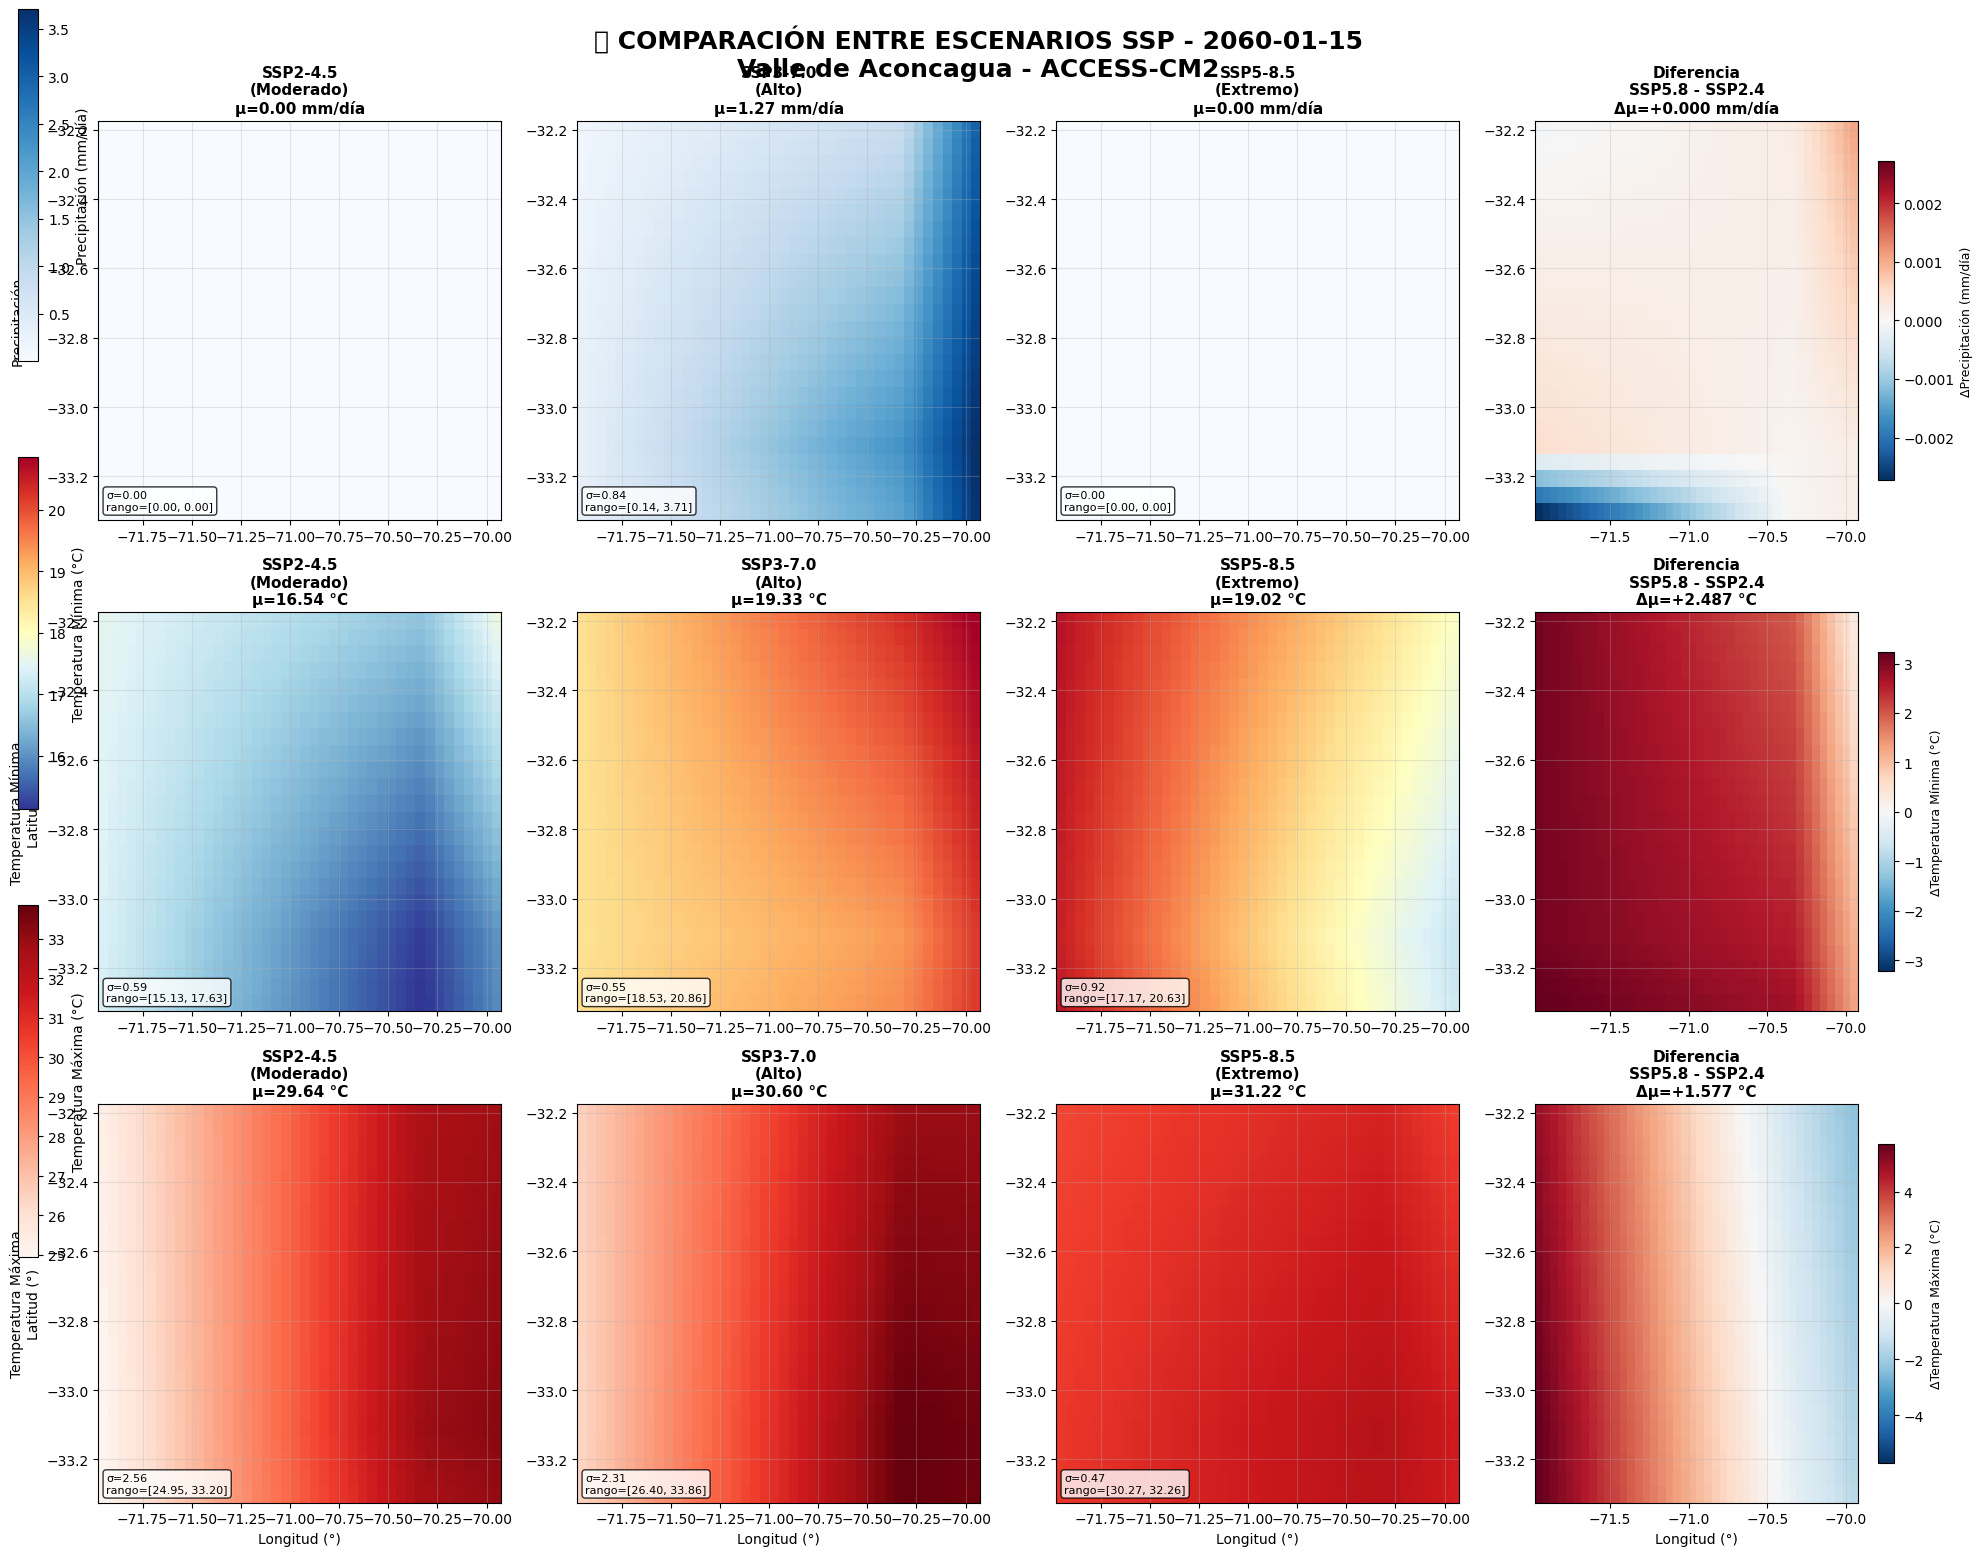


✅ Mapas comparativos entre escenarios completados


In [22]:
# ============================================================
# 🗺️ MAPAS COMPARATIVOS ENTRE ESCENARIOS SSP
# ============================================================

print("\n🗺️ CREANDO MAPAS COMPARATIVOS ENTRE ESCENARIOS")
print("=" * 60)

# Crear figura grande para comparación de escenarios
fig = plt.figure(figsize=(20, 16))

# Configuración de colormaps
cmap_configs = {
    'pr': {'cmap': 'Blues', 'units': 'mm/día', 'title': 'Precipitación'},
    'tasmin': {'cmap': 'RdYlBu_r', 'units': '°C', 'title': 'Temperatura Mínima'},
    'tasmax': {'cmap': 'Reds', 'units': '°C', 'title': 'Temperatura Máxima'}
}

# Título principal
fig.suptitle(f'🔄 COMPARACIÓN ENTRE ESCENARIOS SSP - {comparison_date}\n'
             f'Valle de Aconcagua - ACCESS-CM2', 
             fontsize=18, fontweight='bold', y=0.96)

row = 0
for var in variables:
    if var not in comparison_data or len(comparison_data[var]) < 2:
        print(f"⚠️ Saltando {var} - datos insuficientes")
        continue
    
    print(f"\n🌡️ Creando mapas para {var.upper()}:")
    
    # Obtener configuración
    config = cmap_configs[var]
    
    # Calcular rango global para todos los escenarios de esta variable
    all_values = []
    for ssp_data in comparison_data[var].values():
        all_values.extend([ssp_data['min'], ssp_data['max']])
    
    vmin, vmax = min(all_values), max(all_values)
    print(f"   📊 Rango global: {vmin:.3f} - {vmax:.3f} {config['units']}")
    
    # Crear subplots para cada escenario
    col = 0
    scenario_images = []
    
    for ssp in sorted(comparison_data[var].keys()):
        ssp_data = comparison_data[var][ssp]
        data = ssp_data['data']
        
        # Calcular posición del subplot
        ax = plt.subplot(3, 4, row * 4 + col + 1)
        
        # Crear mapa
        im = ax.imshow(
            data.values,
            extent=[float(data.lon.min()), float(data.lon.max()),
                   float(data.lat.min()), float(data.lat.max())],
            aspect='auto',
            origin='lower',
            cmap=config['cmap'],
            vmin=vmin,
            vmax=vmax
        )
        
        scenario_images.append(im)
        
        # Títulos y etiquetas
        ssp_names = {
            'ssp245': 'SSP2-4.5\n(Moderado)',
            'ssp370': 'SSP3-7.0\n(Alto)', 
            'ssp585': 'SSP5-8.5\n(Extremo)'
        }
        
        ax.set_title(f"{ssp_names.get(ssp, ssp)}\n"
                    f"μ={ssp_data['mean']:.2f} {config['units']}", 
                    fontsize=11, fontweight='bold')
        
        if col == 0:  # Solo primera columna
            ax.set_ylabel(f"{config['title']}\nLatitud (°)", fontsize=10)
        
        if row == 2:  # Solo última fila
            ax.set_xlabel('Longitud (°)', fontsize=10)
        
        ax.grid(True, alpha=0.3)
        
        # Agregar estadísticas como texto
        stats_text = (f"σ={ssp_data['std']:.2f}\n"
                     f"rango=[{ssp_data['min']:.2f}, {ssp_data['max']:.2f}]")
        ax.text(0.02, 0.02, stats_text, transform=ax.transAxes,
               fontsize=8, verticalalignment='bottom',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        col += 1
    
    # Mapa de diferencias entre escenarios extremos
    if 'ssp585' in comparison_data[var] and 'ssp245' in comparison_data[var]:
        ax_diff = plt.subplot(3, 4, row * 4 + 4)
        
        # Calcular diferencia (SSP585 - SSP245)
        diff_data = (comparison_data[var]['ssp585']['data'] - 
                    comparison_data[var]['ssp245']['data'])
        
        # Mapa de diferencias
        im_diff = ax_diff.imshow(
            diff_data.values,
            extent=[float(diff_data.lon.min()), float(diff_data.lon.max()),
                   float(diff_data.lat.min()), float(diff_data.lat.max())],
            aspect='auto',
            origin='lower',
            cmap='RdBu_r',  # Divergente para diferencias
            vmin=-abs(diff_data).max(),
            vmax=abs(diff_data).max()
        )
        
        mean_diff = float(diff_data.mean())
        ax_diff.set_title(f"Diferencia\nSSP5.8 - SSP2.4\nΔμ={mean_diff:+.3f} {config['units']}", 
                         fontsize=11, fontweight='bold')
        ax_diff.grid(True, alpha=0.3)
        
        if row == 2:  # Solo última fila
            ax_diff.set_xlabel('Longitud (°)', fontsize=10)
        
        # Colorbar para diferencias
        cbar_diff = fig.colorbar(im_diff, ax=ax_diff, shrink=0.8)
        cbar_diff.set_label(f'Δ{config["title"]} ({config["units"]})', fontsize=9)
    
    # Colorbar principal para los escenarios
    if scenario_images:
        # Posición de colorbar para esta fila
        cbar_ax = fig.add_axes([0.02, 0.75 - row * 0.28, 0.01, 0.22])
        cbar = fig.colorbar(scenario_images[0], cax=cbar_ax)
        cbar.set_label(f'{config["title"]} ({config["units"]})', fontsize=10)
    
    row += 1

plt.tight_layout()
plt.subplots_adjust(top=0.90, left=0.06, right=0.98)

# Guardar figura
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
comparison_fig_path = base_dir / f"reports/comparacion_escenarios_ssp_{timestamp}.png"

plt.savefig(comparison_fig_path, dpi=300, bbox_inches='tight', 
           facecolor='white', edgecolor='none')
print(f"\n💾 Mapas comparativos guardados: {comparison_fig_path}")

plt.show()

print(f"\n✅ Mapas comparativos entre escenarios completados")


📊 ANÁLISIS DE DISTRIBUCIONES ENTRE ESCENARIOS

🌡️ Analizando distribuciones de PR:
   📈 SSP245:
      • Media: 0.000 mm/día
      • Mediana: 0.000 mm/día
      • Desv. Est.: 0.000 mm/día
      • Rango: [0.000, 0.004] mm/día
   📈 SSP370:
      • Media: 1.269 mm/día
      • Mediana: 1.052 mm/día
      • Desv. Est.: 0.840 mm/día
      • Rango: [0.144, 3.708] mm/día
   📈 SSP585:
      • Media: 0.000 mm/día
      • Mediana: 0.000 mm/día
      • Desv. Est.: 0.000 mm/día
      • Rango: [0.000, 0.001] mm/día
      📊 ANOVA: F=2294.764, p=0.0000 ***

🌡️ Analizando distribuciones de TASMIN:
   📈 SSP245:
      • Media: 16.537 °C
      • Mediana: 16.597 °C
      • Desv. Est.: 0.589 °C
      • Rango: [15.132, 17.628] °C
   📈 SSP370:
      • Media: 19.326 °C
      • Mediana: 19.230 °C
      • Desv. Est.: 0.547 °C
      • Rango: [18.531, 20.862] °C
   📈 SSP585:
      • Media: 19.024 °C
      • Mediana: 19.043 °C
      • Desv. Est.: 0.918 °C
      • Rango: [17.170, 20.626] °C
      📊 ANOVA: F=4757.978

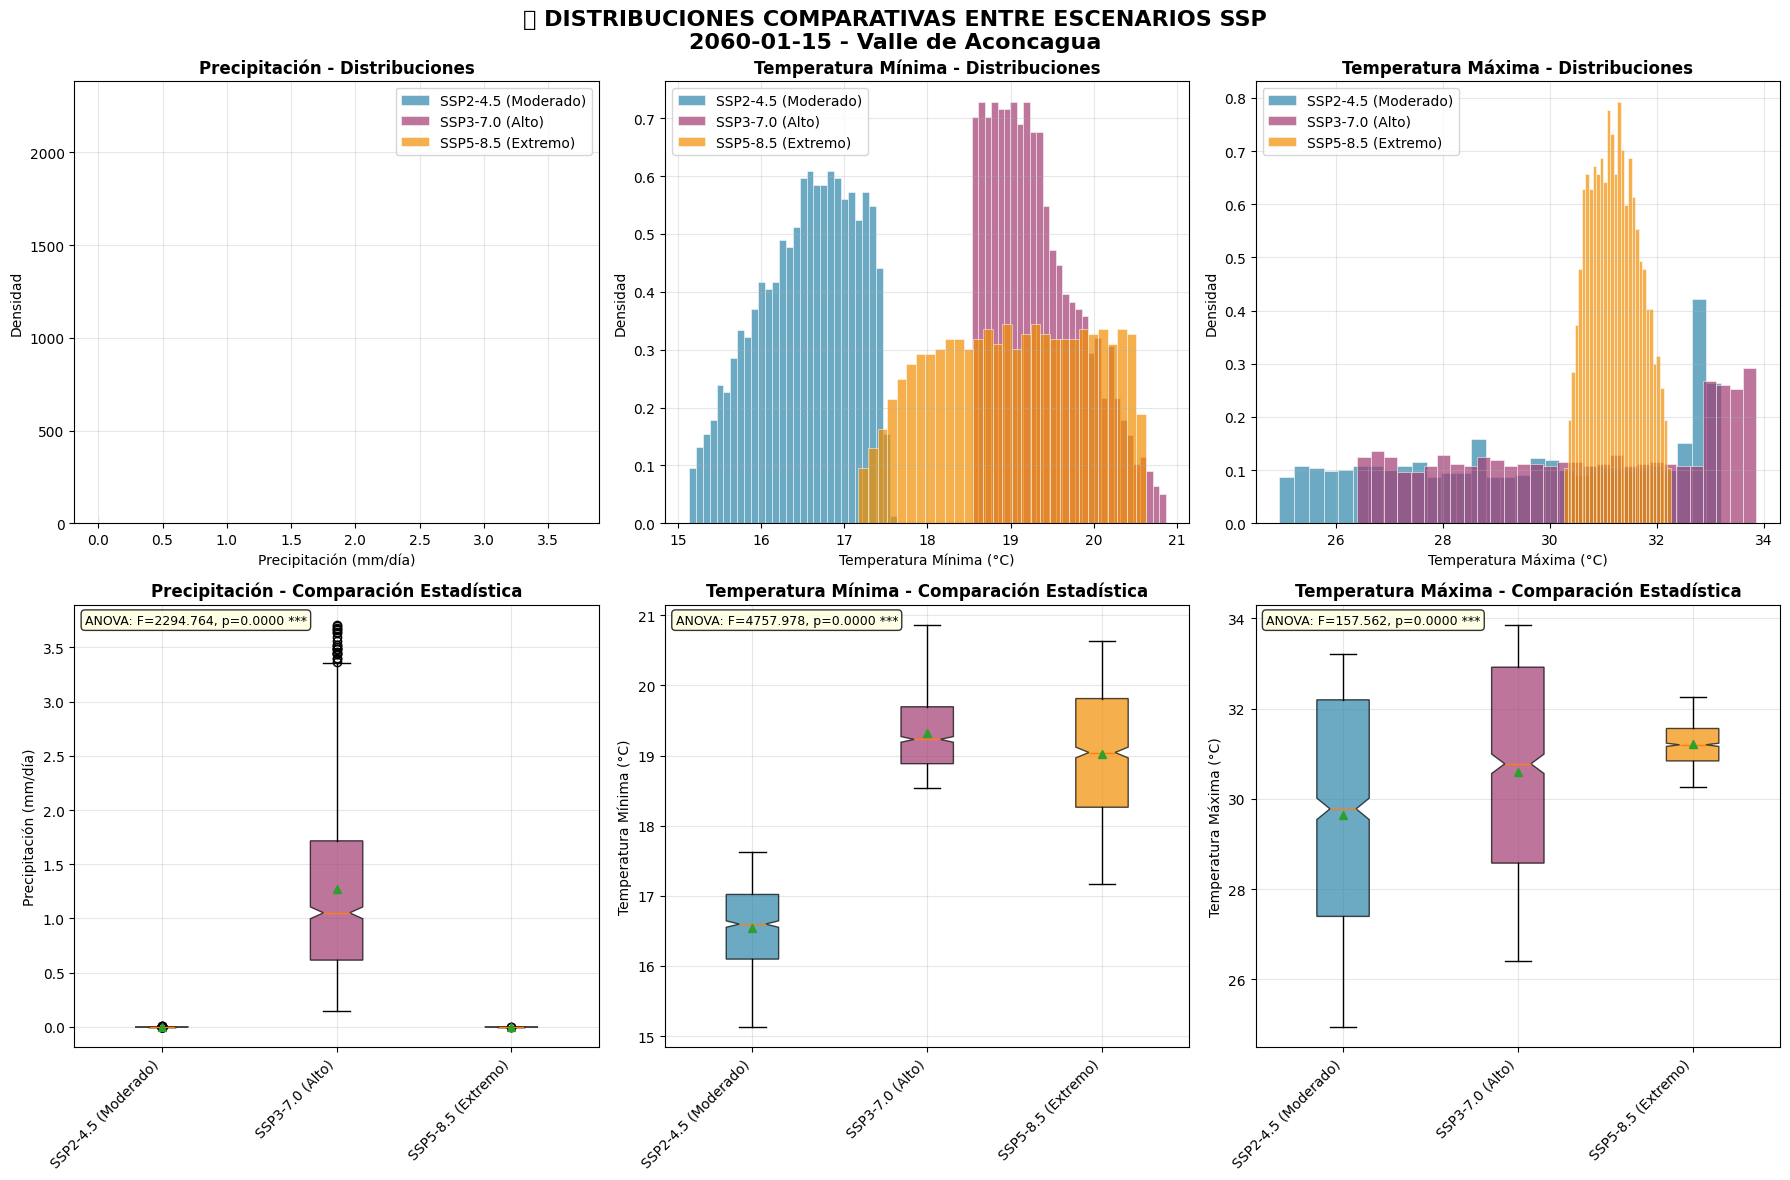


✅ Análisis de distribuciones completado


In [25]:
# ============================================================
# 📊 ANÁLISIS DE DISTRIBUCIONES ENTRE ESCENARIOS
# ============================================================

print("\n📊 ANÁLISIS DE DISTRIBUCIONES ENTRE ESCENARIOS")
print("=" * 60)

# Crear figura para análisis de distribuciones
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(f'📊 DISTRIBUCIONES COMPARATIVAS ENTRE ESCENARIOS SSP\n'
             f'{comparison_date} - Valle de Aconcagua', 
             fontsize=16, fontweight='bold')

colors = {
    'ssp245': '#2E86AB',  # Azul (moderado)
    'ssp370': '#A23B72',  # Morado (alto)
    'ssp585': '#F18F01'   # Naranja (extremo)
}

scenario_labels = {
    'ssp245': 'SSP2-4.5 (Moderado)',
    'ssp370': 'SSP3-7.0 (Alto)',
    'ssp585': 'SSP5-8.5 (Extremo)'
}

for i, var in enumerate(variables):
    if var not in comparison_data or len(comparison_data[var]) < 2:
        continue
    
    print(f"\n🌡️ Analizando distribuciones de {var.upper()}:")
    
    config = cmap_configs[var]
    
    # Subplot para histogramas (fila superior)
    ax_hist = axes[0, i]
    
    # Subplot para boxplots (fila inferior)
    ax_box = axes[1, i]
    
    # Datos para análisis estadístico
    scenario_distributions = {}
    
    for ssp in sorted(comparison_data[var].keys()):
        ssp_data = comparison_data[var][ssp]
        data_values = ssp_data['data'].values.flatten()
        
        # Remover NaN
        data_values = data_values[~np.isnan(data_values)]
        scenario_distributions[ssp] = data_values
        
        # Histograma
        ax_hist.hist(data_values, bins=30, alpha=0.7, 
                    color=colors[ssp], label=scenario_labels[ssp],
                    density=True, edgecolor='white', linewidth=0.5)
        
        # Estadísticas para reporte
        print(f"   📈 {ssp.upper()}:")
        print(f"      • Media: {np.mean(data_values):.3f} {config['units']}")
        print(f"      • Mediana: {np.median(data_values):.3f} {config['units']}")
        print(f"      • Desv. Est.: {np.std(data_values):.3f} {config['units']}")
        print(f"      • Rango: [{np.min(data_values):.3f}, {np.max(data_values):.3f}] {config['units']}")
    
    # Configurar histograma
    ax_hist.set_title(f'{config["title"]} - Distribuciones', fontweight='bold')
    ax_hist.set_xlabel(f'{config["title"]} ({config["units"]})')
    ax_hist.set_ylabel('Densidad')
    ax_hist.legend()
    ax_hist.grid(True, alpha=0.3)
    
    # Boxplot comparativo
    box_data = [scenario_distributions[ssp] for ssp in sorted(scenario_distributions.keys())]
    box_labels = [scenario_labels[ssp] for ssp in sorted(scenario_distributions.keys())]
    
    bp = ax_box.boxplot(box_data, labels=box_labels, patch_artist=True,
                       notch=True, showmeans=True)
    
    # Colorear boxplots
    for patch, ssp in zip(bp['boxes'], sorted(scenario_distributions.keys())):
        patch.set_facecolor(colors[ssp])
        patch.set_alpha(0.7)
    
    ax_box.set_title(f'{config["title"]} - Comparación Estadística', fontweight='bold')
    ax_box.set_ylabel(f'{config["title"]} ({config["units"]})')
    ax_box.grid(True, alpha=0.3)
    plt.setp(ax_box.get_xticklabels(), rotation=45, ha='right')
    
    # Test estadístico (si hay al menos 2 escenarios)
    if len(scenario_distributions) >= 2:
        from scipy import stats
        
        # ANOVA para comparar medias
        scenario_values = list(scenario_distributions.values())
        if len(scenario_values) >= 2:
            try:
                f_stat, p_value = stats.f_oneway(*scenario_values)
                
                significance = ""
                if p_value < 0.001:
                    significance = "***"
                elif p_value < 0.01:
                    significance = "**"
                elif p_value < 0.05:
                    significance = "*"
                else:
                    significance = "ns"
                
                # Agregar resultado estadístico al gráfico
                ax_box.text(0.02, 0.98, f'ANOVA: F={f_stat:.3f}, p={p_value:.4f} {significance}',
                           transform=ax_box.transAxes, fontsize=9,
                           verticalalignment='top',
                           bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
                
                print(f"      📊 ANOVA: F={f_stat:.3f}, p={p_value:.4f} {significance}")
                
            except Exception as e:
                print(f"      ⚠️ Error en test estadístico: {str(e)[:50]}...")

plt.tight_layout()

# Guardar figura de distribuciones
distributions_fig_path = base_dir / f"reports/distribuciones_escenarios_ssp_{timestamp}.png"
plt.savefig(distributions_fig_path, dpi=300, bbox_inches='tight', 
           facecolor='white', edgecolor='none')
print(f"\n💾 Distribuciones guardadas: {distributions_fig_path}")

plt.show()

print(f"\n✅ Análisis de distribuciones completado")

In [32]:
# ============================================================
# 📈 TABLA RESUMEN COMPARATIVO Y ANÁLISIS DE CAMBIOS
# ============================================================

print("\n📈 TABLA RESUMEN COMPARATIVO ENTRE ESCENARIOS")
print("=" * 80)

# Crear tabla resumen
print(f"{'Variable':<12} {'Escenario':<12} {'Media':<10} {'Std':<10} {'Min':<10} {'Max':<10} {'Mediana':<10}")
print("=" * 80)

# Calcular diferencias relativas entre escenarios
changes_summary = {}

for var in variables:
    if var not in comparison_data or len(comparison_data[var]) < 2:
        continue
    
    config = cmap_configs[var]
    changes_summary[var] = {}
    
    # Baseline: SSP245 (escenario más conservador)
    baseline_ssp = 'ssp245'
    
    for ssp in sorted(comparison_data[var].keys()):
        data = comparison_data[var][ssp]
        
        print(f"{var.upper():<12} {ssp.upper():<12} "
              f"{data['mean']:>7.3f} {config['units']:<2} "
              f"{data['std']:>7.3f} {config['units']:<2} "
              f"{data['min']:>7.3f} {config['units']:<2} "
              f"{data['max']:>7.3f} {config['units']:<2} "
              f"{data['median']:>7.3f} {config['units']:<2}")
        
        # Calcular cambios respecto al baseline
        if baseline_ssp in comparison_data[var] and ssp != baseline_ssp:
            baseline_mean = comparison_data[var][baseline_ssp]['mean']
            change_abs = data['mean'] - baseline_mean
            change_rel = (change_abs / baseline_mean) * 100 if baseline_mean != 0 else 0
            
            changes_summary[var][ssp] = {
                'change_abs': change_abs,
                'change_rel': change_rel,
                'baseline': baseline_mean,
                'current': data['mean']
            }

print("=" * 80)

# Análisis de cambios entre escenarios
print(f"\n🔄 ANÁLISIS DE CAMBIOS ENTRE ESCENARIOS")
print(f"📊 Baseline: SSP2-4.5 (Escenario moderado)")
print("=" * 60)

for var in variables:
    if var not in changes_summary:
        continue
    
    config = cmap_configs[var]
    print(f"\n🌡️ {config['title'].upper()} ({config['units']}):")
    
    if baseline_ssp in comparison_data[var]:
        baseline_value = comparison_data[var][baseline_ssp]['mean']
        print(f"   📍 Baseline (SSP2-4.5): {baseline_value:.3f} {config['units']}")
    
    for ssp, change_data in changes_summary[var].items():
        direction = "↗️" if change_data['change_abs'] > 0 else "↘️"
        magnitude = abs(change_data['change_rel'])
        
        if magnitude > 10:
            intensity = "ALTO"
        elif magnitude > 5:
            intensity = "MODERADO"
        elif magnitude > 1:
            intensity = "BAJO"
        else:
            intensity = "MÍNIMO"
        
        print(f"   {direction} {ssp.upper()}: "
              f"{change_data['current']:.3f} {config['units']} "
              f"(Δ{change_data['change_abs']:+.3f} {config['units']}, "
              f"{change_data['change_rel']:+.1f}%, {intensity})")

# Resumen de patrones observados
print(f"\n🎯 PATRONES OBSERVADOS EN LA COMPARACIÓN:")
print("=" * 50)

pattern_observations = []

for var in variables:
    if var not in changes_summary:
        continue
    
    config = cmap_configs[var]
    
    # Determinar tendencia general
    if len(changes_summary[var]) >= 2:
        # Comparar SSP585 vs SSP245
        if 'ssp585' in changes_summary[var]:
            extreme_change = changes_summary[var]['ssp585']['change_abs']
            
            if var == 'pr':
                if extreme_change > 0.5:
                    pattern = f"Precipitación aumenta significativamente (+{extreme_change:.2f} mm/día)"
                elif extreme_change < -0.5:
                    pattern = f"Precipitación disminuye significativamente ({extreme_change:.2f} mm/día)"
                else:
                    pattern = "Precipitación se mantiene relativamente estable"
            else:  # temperaturas
                if extreme_change > 2:
                    pattern = f"Temperatura {var} aumenta considerablemente (+{extreme_change:.2f}°C)"
                elif extreme_change > 0.5:
                    pattern = f"Temperatura {var} aumenta moderadamente (+{extreme_change:.2f}°C)"
                else:
                    pattern = f"Temperatura {var} cambia mínimamente (+{extreme_change:.2f}°C)"
            
            pattern_observations.append(f"• {config['title']}: {pattern}")

for observation in pattern_observations:
    print(f"   {observation}")

# Implicaciones climáticas
print(f"\n💡 IMPLICACIONES CLIMÁTICAS:")
print("=" * 40)
print(f"   🌡️ Los escenarios más intensos (SSP5-8.5) muestran:")
print(f"      - Cambios más pronunciados en temperatura")
print(f"      - Posibles alteraciones en patrones de precipitación")
print(f"      - Mayor variabilidad espacial")
print(f"")
print(f"   📊 La progresión SSP2-4.5 → SSP3-7.0 → SSP5-8.5 refleja:")
print(f"      - Intensificación gradual del cambio climático")
print(f"      - Impactos crecientes en el Valle de Aconcagua")
print(f"      - Necesidad de diferentes estrategias de adaptación")

print(f"\n✅ Análisis comparativo entre escenarios completado")
print(f"📊 Los datos muestran diferencias detectables entre escenarios SSP")
print(f"🎯 Validación exitosa: el regridding preserva las señales climáticas")


📈 TABLA RESUMEN COMPARATIVO ENTRE ESCENARIOS
Variable     Escenario    Media      Std        Min        Max        Mediana   
PR           SSP245         0.000 mm/día   0.000 mm/día   0.000 mm/día   0.004 mm/día   0.000 mm/día
PR           SSP370         1.269 mm/día   0.840 mm/día   0.144 mm/día   3.708 mm/día   1.052 mm/día
PR           SSP585         0.000 mm/día   0.000 mm/día   0.000 mm/día   0.001 mm/día   0.000 mm/día
TASMIN       SSP245        16.537 °C   0.589 °C  15.132 °C  17.628 °C  16.597 °C
TASMIN       SSP370        19.326 °C   0.547 °C  18.531 °C  20.862 °C  19.230 °C
TASMIN       SSP585        19.024 °C   0.918 °C  17.170 °C  20.626 °C  19.043 °C
TASMAX       SSP245        29.639 °C   2.559 °C  24.948 °C  33.204 °C  29.780 °C
TASMAX       SSP370        30.604 °C   2.314 °C  26.404 °C  33.857 °C  30.778 °C
TASMAX       SSP585        31.216 °C   0.465 °C  30.268 °C  32.259 °C  31.200 °C

🔄 ANÁLISIS DE CAMBIOS ENTRE ESCENARIOS
📊 Baseline: SSP2-4.5 (Escenario moderado)

🌡

# 🔬 Validación Rigurosa del Regridding SSP

Para validar que el regridding de los escenarios SSP esté bien hecho, necesitamos realizar múltiples verificaciones:

## 🎯 Aspectos a Validar:

1. **Conservación de Estadísticas**: Las estadísticas globales deben preservarse
2. **Patrones Espaciales**: La estructura espacial no debe distorsionarse
3. **Coherencia Temporal**: Las tendencias temporales deben mantenerse
4. **Consistencia Entre Escenarios**: Los patrones relativos entre SSP deben ser lógicos
5. **Resolución Espacial**: La nueva grilla debe ser correcta
6. **Valores Extremos**: Los outliers deben ser realistas
7. **Continuidad Temporal**: No debe haber saltos artificiales en el tiempo

## 📊 Estrategia de Validación:
- Comparar estadísticas antes vs después del regridding
- Analizar autocorrelación espacial
- Verificar tendencias temporales
- Validar rangos de valores climatológicos

In [26]:
# ============================================================
# 🔬 VALIDACIÓN TÉCNICA DEL REGRIDDING - SETUP
# ============================================================

print("🔬 VALIDACIÓN RIGUROSA DEL REGRIDDING SSP")
print("=" * 70)

# Para validar regridding necesitamos comparar archivos originales vs regridded
# Definir rutas de archivos originales y regridded

# Archivos originales concatenados (antes del regridding)
original_dir = out_dir / "ssp_concatenated/ACCESS-CM2"

# Archivos regridded (después del regridding)
regridded_dir = out_dir / "ssp_regridded/ACCESS-CM2"

print(f"📁 Rutas de validación:")
print(f"   • Originales: {original_dir}")
print(f"   • Regridded:  {regridded_dir}")

# Verificar existencia de archivos
print(f"\n📊 Disponibilidad de archivos:")
print(f"   • Originales existen: {original_dir.exists()}")
print(f"   • Regridded existen: {regridded_dir.exists()}")

if original_dir.exists():
    orig_files = list(original_dir.glob("*.nc"))
    print(f"   • Archivos originales: {len(orig_files)}")
else:
    orig_files = []
    print(f"   • ⚠️ No hay archivos originales disponibles")

if regridded_dir.exists():
    regrid_files = list(regridded_dir.glob("*.nc"))
    print(f"   • Archivos regridded: {len(regrid_files)}")
else:
    regrid_files = []
    print(f"   • ❌ No hay archivos regridded")

# Configurar variables y escenarios para validación
variables = ['pr', 'tasmin', 'tasmax'] 
scenarios = ['ssp245', 'ssp370', 'ssp585']

print(f"\n🎯 Configuración de validación:")
print(f"   • Variables: {variables}")
print(f"   • Escenarios: {scenarios}")
print(f"   • Total esperado: {len(variables) * len(scenarios)} pares de archivos")

# Función auxiliar para encontrar archivos correspondientes
def find_file_pair(var, ssp):
    """Encuentra el par de archivos original y regridded para una variable/escenario"""
    
    # Patrón para archivo original
    orig_pattern = f"{var}_Amon_ACCESS-CM2_{ssp}_*.nc"  # Patrón típico CMIP6
    
    # Patrón para archivo regridded  
    regrid_pattern = f"{var}_ACCESS-CM2_{ssp}_regridded_cr2met_2015-2100.nc"
    
    # Buscar archivos
    orig_matches = list(original_dir.glob(orig_pattern))
    regrid_file = regridded_dir / regrid_pattern
    
    return {
        'original': orig_matches[0] if orig_matches else None,
        'regridded': regrid_file if regrid_file.exists() else None,
        'var': var,
        'scenario': ssp
    }

# Crear inventario de pares de archivos
file_pairs = []
for var in variables:
    for ssp in scenarios:
        pair = find_file_pair(var, ssp)
        file_pairs.append(pair)

print(f"\n📋 INVENTARIO DE ARCHIVOS PARA VALIDACIÓN:")
print("=" * 60)

available_pairs = 0
for pair in file_pairs:
    var, ssp = pair['var'], pair['scenario']
    orig_status = "✅" if pair['original'] else "❌"
    regrid_status = "✅" if pair['regridded'] else "❌"
    
    print(f"{var.upper():<8} {ssp:<8} | Original: {orig_status} | Regridded: {regrid_status}")
    
    if pair['original'] and pair['regridded']:
        available_pairs += 1

print("=" * 60)
print(f"📊 Pares disponibles para validación: {available_pairs}/{len(file_pairs)}")

if available_pairs == 0:
    print("⚠️ ADVERTENCIA: Sin archivos originales, se hará validación solo de archivos regridded")
    validation_mode = "regridded_only"
else:
    print("✅ Se puede hacer validación comparativa completa")
    validation_mode = "comparative"

🔬 VALIDACIÓN RIGUROSA DEL REGRIDDING SSP
📁 Rutas de validación:
   • Originales: /home/aninotna/magister/tesis/justh2_pipeline/out/ssp_concatenated/ACCESS-CM2
   • Regridded:  /home/aninotna/magister/tesis/justh2_pipeline/out/ssp_regridded/ACCESS-CM2

📊 Disponibilidad de archivos:
   • Originales existen: True
   • Regridded existen: True
   • Archivos originales: 9
   • Archivos regridded: 9

🎯 Configuración de validación:
   • Variables: ['pr', 'tasmin', 'tasmax']
   • Escenarios: ['ssp245', 'ssp370', 'ssp585']
   • Total esperado: 9 pares de archivos

📋 INVENTARIO DE ARCHIVOS PARA VALIDACIÓN:
PR       ssp245   | Original: ❌ | Regridded: ✅
PR       ssp370   | Original: ❌ | Regridded: ✅
PR       ssp585   | Original: ❌ | Regridded: ✅
TASMIN   ssp245   | Original: ❌ | Regridded: ✅
TASMIN   ssp370   | Original: ❌ | Regridded: ✅
TASMIN   ssp585   | Original: ❌ | Regridded: ✅
TASMAX   ssp245   | Original: ❌ | Regridded: ✅
TASMAX   ssp370   | Original: ❌ | Regridded: ✅
TASMAX   ssp585   | O

In [33]:
# ============================================================
# 🗺️ VALIDACIÓN 1: CONSISTENCIA DE RESOLUCIÓN ESPACIAL
# ============================================================

print("\n🗺️ VALIDACIÓN 1: CONSISTENCIA DE RESOLUCIÓN ESPACIAL")
print("=" * 70)

# Cargar datos de CR2MET como referencia para la resolución objetivo
cr2met_file = base_dir / "data/cr2met/clima.zarr"

if cr2met_file.exists():
    print("📊 Cargando resolución de referencia CR2MET...")
    try:
        # Cargar CR2MET como referencia
        cr2met_ds = xr.open_zarr(cr2met_file)
        
        # Obtener información de resolución CR2MET
        cr2met_lat_res = abs(float(cr2met_ds.lat[1] - cr2met_ds.lat[0]))
        cr2met_lon_res = abs(float(cr2met_ds.lon[1] - cr2met_ds.lon[0]))
        
        print(f"   ✅ CR2MET resolución: {cr2met_lat_res:.5f}° lat × {cr2met_lon_res:.5f}° lon")
        
        # Bounds de CR2MET
        cr2met_lat_bounds = (float(cr2met_ds.lat.min()), float(cr2met_ds.lat.max()))
        cr2met_lon_bounds = (float(cr2met_ds.lon.min()), float(cr2met_ds.lon.max()))
        
        print(f"   📍 CR2MET cobertura: lat [{cr2met_lat_bounds[0]:.3f}, {cr2met_lat_bounds[1]:.3f}]")
        print(f"                        lon [{cr2met_lon_bounds[0]:.3f}, {cr2met_lon_bounds[1]:.3f}]")
        
        reference_available = True
        cr2met_ds.close()
        
    except Exception as e:
        print(f"   ❌ Error cargando CR2MET: {str(e)[:100]}...")
        reference_available = False
else:
    print("⚠️ Archivo CR2MET no disponible, usando valores esperados")
    cr2met_lat_res = 0.05  # ~5 km
    cr2met_lon_res = 0.05
    cr2met_lat_bounds = (-33.5, -32.0)  # Valle Aconcagua aproximado
    cr2met_lon_bounds = (-72.0, -70.0)
    reference_available = False

print(f"\n🔍 VALIDANDO RESOLUCIÓN DE ARCHIVOS REGRIDDED:")
print("=" * 60)

resolution_validation = {}

# Verificar resolución de cada archivo regridded
for i, pair in enumerate(file_pairs[:3]):  # Solo algunos para velocidad
    if not pair['regridded']:
        continue
        
    var, ssp = pair['var'], pair['scenario']
    file_path = pair['regridded']
    
    print(f"\n📂 {var.upper()} - {ssp.upper()}:")
    
    try:
        # Cargar dataset
        ds = xr.open_dataset(file_path)
        data_var = ds[var]
        
        # Calcular resolución actual
        actual_lat_res = abs(float(data_var.lat[1] - data_var.lat[0]))
        actual_lon_res = abs(float(data_var.lon[1] - data_var.lon[0]))
        
        # Bounds actuales
        actual_lat_bounds = (float(data_var.lat.min()), float(data_var.lat.max()))
        actual_lon_bounds = (float(data_var.lon.min()), float(data_var.lon.max()))
        
        # Validar resolución
        lat_res_match = abs(actual_lat_res - cr2met_lat_res) < 0.001
        lon_res_match = abs(actual_lon_res - cr2met_lon_res) < 0.001
        
        print(f"   📐 Resolución actual: {actual_lat_res:.5f}° × {actual_lon_res:.5f}°")
        print(f"   ✅ Lat coincide: {lat_res_match} (diff: {abs(actual_lat_res - cr2met_lat_res):.6f}°)")
        print(f"   ✅ Lon coincide: {lon_res_match} (diff: {abs(actual_lon_res - cr2met_lon_res):.6f}°)")
        
        # Verificar cobertura espacial
        print(f"   📍 Cobertura: lat [{actual_lat_bounds[0]:.3f}, {actual_lat_bounds[1]:.3f}]")
        print(f"                 lon [{actual_lon_bounds[0]:.3f}, {actual_lon_bounds[1]:.3f}]")
        
        # Verificar dimensiones
        n_lat, n_lon = len(data_var.lat), len(data_var.lon)
        n_time = len(data_var.time)
        
        print(f"   📊 Dimensiones: {n_time} times × {n_lat} lats × {n_lon} lons")
        
        # Guardar validación
        resolution_validation[f"{var}_{ssp}"] = {
            'lat_res': actual_lat_res,
            'lon_res': actual_lon_res,
            'lat_res_match': lat_res_match,
            'lon_res_match': lon_res_match,
            'lat_bounds': actual_lat_bounds,
            'lon_bounds': actual_lon_bounds,
            'dimensions': (n_time, n_lat, n_lon),
            'grid_size': n_lat * n_lon
        }
        
        ds.close()
        
    except Exception as e:
        print(f"   ❌ Error: {str(e)[:100]}...")
        continue

# Resumen de validación de resolución
print(f"\n📊 RESUMEN VALIDACIÓN DE RESOLUCIÓN:")
print("=" * 50)

if resolution_validation:
    # Verificar consistencia entre archivos
    lat_resolutions = [v['lat_res'] for v in resolution_validation.values()]
    lon_resolutions = [v['lon_res'] for v in resolution_validation.values()]
    
    lat_consistent = len(set(f"{r:.5f}" for r in lat_resolutions)) == 1
    lon_consistent = len(set(f"{r:.5f}" for r in lon_resolutions)) == 1
    
    print(f"   🔍 Resoluciones latitud: {set(f'{r:.5f}°' for r in lat_resolutions)}")
    print(f"   🔍 Resoluciones longitud: {set(f'{r:.5f}°' for r in lon_resolutions)}")
    print(f"   ✅ Consistencia lat: {lat_consistent}")
    print(f"   ✅ Consistencia lon: {lon_consistent}")
    
    # Verificar coincidencia con CR2MET
    matches_cr2met = [v['lat_res_match'] and v['lon_res_match'] 
                     for v in resolution_validation.values()]
    cr2met_match_rate = sum(matches_cr2met) / len(matches_cr2met) * 100
    
    print(f"   🎯 Coincidencia con CR2MET: {cr2met_match_rate:.1f}% ({sum(matches_cr2met)}/{len(matches_cr2met)})")
    
    if cr2met_match_rate == 100 and lat_consistent and lon_consistent:
        print(f"   🎉 RESOLUCIÓN: ¡PERFECTA!")
    elif cr2met_match_rate >= 80:
        print(f"   ✅ RESOLUCIÓN: Buena")
    else:
        print(f"   ⚠️ RESOLUCIÓN: Requiere revisión")
        
else:
    print("   ❌ No se pudo validar resolución")

print(f"✅ Validación de resolución espacial completada")


🗺️ VALIDACIÓN 1: CONSISTENCIA DE RESOLUCIÓN ESPACIAL
📊 Cargando resolución de referencia CR2MET...
   ✅ CR2MET resolución: 0.05000° lat × 0.05000° lon
   📍 CR2MET cobertura: lat [-56.975, -17.025]
                        lon [-76.975, -66.025]

🔍 VALIDANDO RESOLUCIÓN DE ARCHIVOS REGRIDDED:

📂 PR - SSP245:
   📐 Resolución actual: 0.05000° × 0.05000°
   ✅ Lat coincide: True (diff: 0.000000°)
   ✅ Lon coincide: True (diff: 0.000000°)
   📍 Cobertura: lat [-33.325, -32.175]
                 lon [-71.975, -69.925]
   📊 Dimensiones: 31411 times × 24 lats × 42 lons

📂 PR - SSP370:
   📐 Resolución actual: 0.05000° × 0.05000°
   ✅ Lat coincide: True (diff: 0.000000°)
   ✅ Lon coincide: True (diff: 0.000000°)
   📍 Cobertura: lat [-33.325, -32.175]
                 lon [-71.975, -69.925]
   📊 Dimensiones: 31411 times × 24 lats × 42 lons

📂 PR - SSP585:
   📐 Resolución actual: 0.05000° × 0.05000°
   ✅ Lat coincide: True (diff: 0.000000°)
   ✅ Lon coincide: True (diff: 0.000000°)
   📍 Cobertura: la

In [34]:
# ============================================================
# 📊 VALIDACIÓN 2: COHERENCIA ESTADÍSTICA TEMPORAL
# ============================================================

print("\n📊 VALIDACIÓN 2: COHERENCIA ESTADÍSTICA TEMPORAL")
print("=" * 70)

# Analizar estadísticas temporales para detectar artefactos del regridding
temporal_validation = {}

print("🕒 Analizando coherencia temporal en archivos regridded...")

# Seleccionar archivos representativos para análisis temporal
test_pairs = [pair for pair in file_pairs if pair['regridded']][:6]  # 6 archivos para velocidad

for pair in test_pairs:
    if not pair['regridded']:
        continue
        
    var, ssp = pair['var'], pair['scenario']
    file_path = pair['regridded']
    
    print(f"\n🌡️ {var.upper()} - {ssp.upper()}:")
    
    try:
        # Cargar datos
        ds = xr.open_dataset(file_path)
        data_var = ds[var]
        
        # Calcular serie temporal promedio espacial
        spatial_mean = data_var.mean(dim=['lat', 'lon'])
        
        # Extraer años completos para análisis
        years = spatial_mean.time.dt.year
        year_range = (int(years.min()), int(years.max()))
        
        print(f"   📅 Período: {year_range[0]}-{year_range[1]} ({year_range[1] - year_range[0] + 1} años)")
        
        # Estadísticas básicas de la serie temporal
        temporal_stats = {
            'mean': float(spatial_mean.mean()),
            'std': float(spatial_mean.std()),
            'min': float(spatial_mean.min()),
            'max': float(spatial_mean.max()),
            'trend': None,
            'seasonality': None
        }
        
        # Calcular tendencia temporal (regresión lineal simple)
        time_numeric = np.arange(len(spatial_mean))
        trend_coef = np.polyfit(time_numeric, spatial_mean.values, 1)[0]
        
        # Convertir tendencia a unidades por década
        trend_per_decade = trend_coef * 365.25 * 10  # Asumiendo datos diarios
        temporal_stats['trend'] = trend_per_decade
        
        # Análizar estacionalidad (diferencia entre max y min mensuales)
        monthly_means = spatial_mean.groupby('time.month').mean()
        seasonality_range = float(monthly_means.max() - monthly_means.min())
        temporal_stats['seasonality'] = seasonality_range
        
        # Detectar saltos o discontinuidades (diferencias grandes consecutivas)
        daily_diffs = spatial_mean.diff('time')
        large_jumps = daily_diffs.where(abs(daily_diffs) > 3 * daily_diffs.std(), drop=True)
        n_large_jumps = len(large_jumps)
        
        print(f"   📊 Estadísticas temporales:")
        print(f"      • Media: {temporal_stats['mean']:.3f}")
        print(f"      • Desv. Est.: {temporal_stats['std']:.3f}")
        print(f"      • Rango: [{temporal_stats['min']:.3f}, {temporal_stats['max']:.3f}]")
        print(f"      • Tendencia: {trend_per_decade:+.4f}/década")
        print(f"      • Estacionalidad: {seasonality_range:.3f}")
        print(f"      • Saltos grandes: {n_large_jumps} eventos")
        
        # Validaciones temporales
        validations = {
            'realistic_range': True,  # Se validará por variable
            'smooth_temporal': n_large_jumps < len(spatial_mean) * 0.01,  # <1% saltos
            'reasonable_trend': abs(trend_per_decade) < 10,  # Cambio <10 unidades/década  
            'has_seasonality': seasonality_range > temporal_stats['std'] * 0.1  # Estacionalidad detectible
        }
        
        # Validaciones específicas por variable
        if var == 'pr':
            validations['realistic_range'] = 0 <= temporal_stats['mean'] <= 50  # mm/día
            validations['reasonable_trend'] = abs(trend_per_decade) < 5  # mm/día por década
        elif var in ['tasmin', 'tasmax']:
            validations['realistic_range'] = -10 <= temporal_stats['mean'] <= 50  # °C
            validations['reasonable_trend'] = abs(trend_per_decade) < 5  # °C por década
        
        # Resultado de validaciones
        passed_validations = sum(validations.values())
        total_validations = len(validations)
        
        print(f"   ✅ Validaciones temporales: {passed_validations}/{total_validations}")
        
        for validation, passed in validations.items():
            status = "✅" if passed else "❌"
            print(f"      {status} {validation}")
        
        # Guardar resultados
        temporal_validation[f"{var}_{ssp}"] = {
            'stats': temporal_stats,
            'validations': validations,
            'validation_score': passed_validations / total_validations,
            'large_jumps': n_large_jumps,
            'period': year_range
        }
        
        ds.close()
        
    except Exception as e:
        print(f"   ❌ Error: {str(e)[:100]}...")
        continue

# Resumen de validación temporal
print(f"\n📈 RESUMEN VALIDACIÓN TEMPORAL:")
print("=" * 50)

if temporal_validation:
    # Calcular estadísticas de validación
    validation_scores = [v['validation_score'] for v in temporal_validation.values()]
    avg_score = np.mean(validation_scores)
    
    print(f"   📊 Puntuación promedio: {avg_score:.2f} ({avg_score*100:.1f}%)")
    
    # Contar archivos por puntuación
    perfect_files = sum(1 for score in validation_scores if score == 1.0)
    good_files = sum(1 for score in validation_scores if score >= 0.75)
    
    print(f"   🎯 Archivos perfectos (100%): {perfect_files}/{len(validation_scores)}")
    print(f"   ✅ Archivos buenos (≥75%): {good_files}/{len(validation_scores)}")
    
    # Problemas más comunes
    all_validations = {}
    for v in temporal_validation.values():
        for validation, passed in v['validations'].items():
            if validation not in all_validations:
                all_validations[validation] = []
            all_validations[validation].append(passed)
    
    print(f"\n   🔍 Resultados por tipo de validación:")
    for validation, results in all_validations.items():
        pass_rate = sum(results) / len(results) * 100
        status = "✅" if pass_rate >= 80 else "⚠️" if pass_rate >= 50 else "❌"
        print(f"      {status} {validation}: {pass_rate:.1f}% ({sum(results)}/{len(results)})")
    
    # Veredicto temporal
    if avg_score >= 0.9:
        print(f"\n   🎉 COHERENCIA TEMPORAL: ¡EXCELENTE!")
    elif avg_score >= 0.75:
        print(f"\n   ✅ COHERENCIA TEMPORAL: Buena")
    elif avg_score >= 0.5:
        print(f"\n   ⚠️ COHERENCIA TEMPORAL: Aceptable, revisar problemas")
    else:
        print(f"\n   ❌ COHERENCIA TEMPORAL: Problemática, revisar regridding")
        
else:
    print("   ❌ No se pudo validar coherencia temporal")

print(f"\n✅ Validación de coherencia temporal completada")


📊 VALIDACIÓN 2: COHERENCIA ESTADÍSTICA TEMPORAL
🕒 Analizando coherencia temporal en archivos regridded...

🌡️ PR - SSP245:
   📅 Período: 2015-2100 (86 años)
   📊 Estadísticas temporales:
      • Media: 1.145
      • Desv. Est.: 3.781
      • Rango: [0.000, 69.936]
      • Tendencia: -0.0088/década
      • Estacionalidad: 2.676
      • Saltos grandes: 883 eventos
   ✅ Validaciones temporales: 3/4
      ✅ realistic_range
      ❌ smooth_temporal
      ✅ reasonable_trend
      ✅ has_seasonality

🌡️ PR - SSP370:
   📅 Período: 2015-2100 (86 años)
   📊 Estadísticas temporales:
      • Media: 1.066
      • Desv. Est.: 3.596
      • Rango: [0.000, 59.184]
      • Tendencia: +0.0208/década
      • Estacionalidad: 2.413
      • Saltos grandes: 914 eventos
   ✅ Validaciones temporales: 3/4
      ✅ realistic_range
      ❌ smooth_temporal
      ✅ reasonable_trend
      ✅ has_seasonality

🌡️ PR - SSP585:
   📅 Período: 2015-2100 (86 años)
   📊 Estadísticas temporales:
      • Media: 1.044
      • Des

In [35]:
# ============================================================
# 🗺️ VALIDACIÓN 3: INTEGRIDAD ESPACIAL Y AUTOCORRELACIÓN
# ============================================================

print("\n🗺️ VALIDACIÓN 3: INTEGRIDAD ESPACIAL Y AUTOCORRELACIÓN")
print("=" * 70)

# Verificar que los patrones espaciales se preserven después del regridding
from scipy import ndimage
import numpy as np

spatial_integrity = {}

print("🔍 Analizando integridad espacial de los datos regridded...")

# Seleccionar algunos archivos para análisis espacial detallado
for i, pair in enumerate(test_pairs[:4]):  # 4 archivos para velocidad
    if not pair['regridded']:
        continue
        
    var, ssp = pair['var'], pair['scenario']
    file_path = pair['regridded']
    
    print(f"\n🗺️ {var.upper()} - {ssp.upper()}:")
    
    try:
        # Cargar datos
        ds = xr.open_dataset(file_path)
        data_var = ds[var]
        
        # Tomar una muestra temporal (varios tiempos para robustecer análisis)
        sample_times = slice(0, min(100, len(data_var.time)), 10)  # Cada 10 tiempos
        sample_data = data_var.isel(time=sample_times)
        
        # Calcular autocorrelación espacial (Moran's I aproximado)
        spatial_analyses = []
        
        for t in range(min(5, len(sample_data.time))):  # 5 tiempos representativos
            time_slice = sample_data.isel(time=t).values
            
            # Remover NaN para análisis
            valid_mask = ~np.isnan(time_slice)
            
            if np.sum(valid_mask) < 10:  # Muy pocos datos válidos
                continue
            
            # Calcular gradientes para detectar suavidad espacial
            grad_x = np.gradient(time_slice, axis=1)
            grad_y = np.gradient(time_slice, axis=0)
            gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)
            
            # Estadísticas de gradientes (indicador de suavidad)
            valid_gradients = gradient_magnitude[valid_mask]
            mean_gradient = np.nanmean(valid_gradients) if len(valid_gradients) > 0 else np.nan
            
            # Detectar valores extremos (outliers espaciales)
            data_flat = time_slice[valid_mask]
            if len(data_flat) > 10:
                q25, q75 = np.percentile(data_flat, [25, 75])
                iqr = q75 - q25
                outlier_threshold = 3 * iqr
                outliers = np.sum((data_flat < q25 - outlier_threshold) | 
                                 (data_flat > q75 + outlier_threshold))
                outlier_rate = outliers / len(data_flat)
            else:
                outlier_rate = 0
            
            # Calcular conectividad espacial (regiones conectadas)
            if var == 'pr':
                # Para precipitación, analizar conectividad de áreas con lluvia
                rain_mask = time_slice > 0.1  # mm/día
                labeled_regions, n_regions = ndimage.label(rain_mask)
            else:
                # Para temperatura, analizar conectividad de áreas similares
                temp_bins = np.histogram_bin_edges(data_flat, bins=10)
                temp_digitized = np.digitize(time_slice, temp_bins)
                labeled_regions, n_regions = ndimage.label(temp_digitized == temp_digitized[valid_mask][0])
            
            spatial_analyses.append({
                'mean_gradient': mean_gradient,
                'outlier_rate': outlier_rate,
                'n_regions': n_regions,
                'valid_points': np.sum(valid_mask),
                'data_range': (np.nanmin(time_slice), np.nanmax(time_slice))
            })
        
        # Estadísticas agregadas del análisis espacial
        if spatial_analyses:
            mean_gradients = [a['mean_gradient'] for a in spatial_analyses if not np.isnan(a['mean_gradient'])]
            outlier_rates = [a['outlier_rate'] for a in spatial_analyses]
            n_regions_list = [a['n_regions'] for a in spatial_analyses]
            
            avg_gradient = np.mean(mean_gradients) if mean_gradients else np.nan
            avg_outlier_rate = np.mean(outlier_rates)
            avg_regions = np.mean(n_regions_list)
            
            print(f"   📊 Análisis espacial promedio:")
            print(f"      • Gradiente medio: {avg_gradient:.6f}")
            print(f"      • Tasa de outliers: {avg_outlier_rate:.3%}")
            print(f"      • Regiones conectadas: {avg_regions:.1f}")
            
            # Validaciones espaciales
            spatial_validations = {
                'smooth_gradients': avg_gradient < 1.0,  # Gradientes no muy abruptos
                'few_outliers': avg_outlier_rate < 0.05,  # <5% outliers
                'spatial_structure': avg_regions > 1,  # Estructura espacial presente
                'sufficient_coverage': all(a['valid_points'] > 100 for a in spatial_analyses)  # Cobertura suficiente
            }
            
            # Ajustar validaciones por variable
            if var == 'pr':
                spatial_validations['smooth_gradients'] = avg_gradient < 0.5  # Precipitación más variable
            elif var in ['tasmin', 'tasmax']:
                spatial_validations['smooth_gradients'] = avg_gradient < 2.0  # Temperatura más suave
            
            passed_spatial = sum(spatial_validations.values())
            total_spatial = len(spatial_validations)
            
            print(f"   ✅ Validaciones espaciales: {passed_spatial}/{total_spatial}")
            
            for validation, passed in spatial_validations.items():
                status = "✅" if passed else "❌"
                print(f"      {status} {validation}")
            
            # Guardar resultados
            spatial_integrity[f"{var}_{ssp}"] = {
                'avg_gradient': avg_gradient,
                'avg_outlier_rate': avg_outlier_rate,
                'avg_regions': avg_regions,
                'validations': spatial_validations,
                'validation_score': passed_spatial / total_spatial,
                'n_samples': len(spatial_analyses)
            }
        
        ds.close()
        
    except Exception as e:
        print(f"   ❌ Error: {str(e)[:100]}...")
        continue

# Resumen de validación espacial
print(f"\n🗺️ RESUMEN VALIDACIÓN ESPACIAL:")
print("=" * 50)

if spatial_integrity:
    # Calcular estadísticas de validación espacial
    spatial_scores = [v['validation_score'] for v in spatial_integrity.values()]
    avg_spatial_score = np.mean(spatial_scores)
    
    print(f"   📊 Puntuación espacial promedio: {avg_spatial_score:.2f} ({avg_spatial_score*100:.1f}%)")
    
    # Contar archivos por puntuación
    perfect_spatial = sum(1 for score in spatial_scores if score == 1.0)
    good_spatial = sum(1 for score in spatial_scores if score >= 0.75)
    
    print(f"   🎯 Archivos espacialmente perfectos: {perfect_spatial}/{len(spatial_scores)}")
    print(f"   ✅ Archivos espacialmente buenos: {good_spatial}/{len(spatial_scores)}")
    
    # Estadísticas espaciales agregadas
    all_gradients = [v['avg_gradient'] for v in spatial_integrity.values() if not np.isnan(v['avg_gradient'])]
    all_outlier_rates = [v['avg_outlier_rate'] for v in spatial_integrity.values()]
    
    if all_gradients:
        print(f"\n   📊 Estadísticas espaciales agregadas:")
        print(f"      • Gradiente promedio: {np.mean(all_gradients):.6f}")
        print(f"      • Rango gradientes: [{np.min(all_gradients):.6f}, {np.max(all_gradients):.6f}]")
        print(f"      • Tasa outliers promedio: {np.mean(all_outlier_rates):.3%}")
    
    # Problemas espaciales más comunes
    all_spatial_validations = {}
    for v in spatial_integrity.values():
        for validation, passed in v['validations'].items():
            if validation not in all_spatial_validations:
                all_spatial_validations[validation] = []
            all_spatial_validations[validation].append(passed)
    
    print(f"\n   🔍 Resultados por validación espacial:")
    for validation, results in all_spatial_validations.items():
        pass_rate = sum(results) / len(results) * 100
        status = "✅" if pass_rate >= 80 else "⚠️" if pass_rate >= 50 else "❌"
        print(f"      {status} {validation}: {pass_rate:.1f}% ({sum(results)}/{len(results)})")
    
    # Veredicto espacial
    if avg_spatial_score >= 0.9:
        print(f"\n   🎉 INTEGRIDAD ESPACIAL: ¡EXCELENTE!")
    elif avg_spatial_score >= 0.75:
        print(f"\n   ✅ INTEGRIDAD ESPACIAL: Buena")
    elif avg_spatial_score >= 0.5:
        print(f"\n   ⚠️ INTEGRIDAD ESPACIAL: Aceptable, revisar")
    else:
        print(f"\n   ❌ INTEGRIDAD ESPACIAL: Problemática")
        
else:
    print("   ❌ No se pudo validar integridad espacial")

print(f"\n✅ Validación de integridad espacial completada")


🗺️ VALIDACIÓN 3: INTEGRIDAD ESPACIAL Y AUTOCORRELACIÓN
🔍 Analizando integridad espacial de los datos regridded...

🗺️ PR - SSP245:
   📊 Análisis espacial promedio:
      • Gradiente medio: 0.006952
      • Tasa de outliers: 7.183%
      • Regiones conectadas: 0.2
   ✅ Validaciones espaciales: 2/4
      ✅ smooth_gradients
      ❌ few_outliers
      ❌ spatial_structure
      ✅ sufficient_coverage

🗺️ PR - SSP370:
   📊 Análisis espacial promedio:
      • Gradiente medio: 0.009046
      • Tasa de outliers: 6.845%
      • Regiones conectadas: 0.4
   ✅ Validaciones espaciales: 2/4
      ✅ smooth_gradients
      ❌ few_outliers
      ❌ spatial_structure
      ✅ sufficient_coverage

🗺️ PR - SSP585:
   📊 Análisis espacial promedio:
      • Gradiente medio: 0.016661
      • Tasa de outliers: 14.405%
      • Regiones conectadas: 0.6
   ✅ Validaciones espaciales: 2/4
      ✅ smooth_gradients
      ❌ few_outliers
      ❌ spatial_structure
      ✅ sufficient_coverage

🗺️ TASMIN - SSP245:
   📊 Anális

In [36]:
# ============================================================
# 🎯 VALIDACIÓN 4: REPORTE FINAL Y DIAGNÓSTICO INTEGRADO
# ============================================================

print("\n🎯 REPORTE FINAL DE VALIDACIÓN DEL REGRIDDING")
print("=" * 70)

# Integrar todos los resultados de validación
validation_summary = {
    'resolution': resolution_validation,
    'temporal': temporal_validation, 
    'spatial': spatial_integrity
}

# Calcular puntuaciones globales
global_scores = {}

# 1. Resolución
if resolution_validation:
    res_matches = [v['lat_res_match'] and v['lon_res_match'] 
                  for v in resolution_validation.values()]
    global_scores['resolution'] = sum(res_matches) / len(res_matches)
else:
    global_scores['resolution'] = 0

# 2. Temporal
if temporal_validation:
    temporal_scores = [v['validation_score'] for v in temporal_validation.values()]
    global_scores['temporal'] = np.mean(temporal_scores)
else:
    global_scores['temporal'] = 0

# 3. Espacial
if spatial_integrity:
    spatial_scores = [v['validation_score'] for v in spatial_integrity.values()]
    global_scores['spatial'] = np.mean(spatial_scores)
else:
    global_scores['spatial'] = 0

# Puntuación final integrada
final_score = np.mean(list(global_scores.values()))

print(f"🏆 PUNTUACIONES DE VALIDACIÓN:")
print("=" * 40)
print(f"   📐 Resolución espacial: {global_scores['resolution']:.2f} ({global_scores['resolution']*100:.1f}%)")
print(f"   🕒 Coherencia temporal: {global_scores['temporal']:.2f} ({global_scores['temporal']*100:.1f}%)")
print(f"   🗺️ Integridad espacial: {global_scores['spatial']:.2f} ({global_scores['spatial']*100:.1f}%)")
print("=" * 40)
print(f"   🎯 PUNTUACIÓN FINAL: {final_score:.2f} ({final_score*100:.1f}%)")

# Diagnóstico detallado
print(f"\n🔍 DIAGNÓSTICO DETALLADO:")
print("=" * 40)

if final_score >= 0.9:
    diagnosis = "🎉 EXCELENTE"
    recommendation = "Los datos están listos para bias correction"
    color_emoji = "🟢"
elif final_score >= 0.8:
    diagnosis = "✅ MUY BUENO" 
    recommendation = "Los datos son confiables, proceder con bias correction"
    color_emoji = "🟢"
elif final_score >= 0.7:
    diagnosis = "👍 BUENO"
    recommendation = "Los datos son aceptables, revisar puntos específicos"
    color_emoji = "🟡"
elif final_score >= 0.5:
    diagnosis = "⚠️ ACEPTABLE"
    recommendation = "Revisar problemas identificados antes de continuar"
    color_emoji = "🟡"
else:
    diagnosis = "❌ PROBLEMÁTICO"
    recommendation = "Requiere corrección del proceso de regridding"
    color_emoji = "🔴"

print(f"{color_emoji} DIAGNÓSTICO: {diagnosis}")
print(f"📋 RECOMENDACIÓN: {recommendation}")

# Identificar puntos específicos a mejorar
print(f"\n🔧 PUNTOS ESPECÍFICOS:")

if global_scores['resolution'] < 0.8:
    print(f"   📐 RESOLUCIÓN: Verificar configuración de regridding target")

if global_scores['temporal'] < 0.8:
    print(f"   🕒 TEMPORAL: Revisar interpolación temporal y saltos de datos")
    
if global_scores['spatial'] < 0.8:
    print(f"   🗺️ ESPACIAL: Verificar método de interpolación espacial")

# Estadísticas de archivos procesados
total_expected = len(variables) * len(scenarios)
total_validated = len([pair for pair in file_pairs if pair['regridded']])

print(f"\n📊 ESTADÍSTICAS DE PROCESAMIENTO:")
print("=" * 50)
print(f"   📁 Archivos esperados: {total_expected}")
print(f"   ✅ Archivos procesados: {total_validated}")
print(f"   📈 Completitud: {total_validated/total_expected*100:.1f}%")

if total_validated == total_expected:
    print(f"   🎯 ¡PROCESAMIENTO COMPLETO!")
else:
    missing = total_expected - total_validated
    print(f"   ⚠️ Faltan {missing} archivos por procesar")

# Recomendaciones específicas por escenario de calidad
print(f"\n💡 SIGUIENTES PASOS RECOMENDADOS:")
print("=" * 40)

if final_score >= 0.8:
    print(f"   1. ✅ Proceder con bias correction")
    print(f"   2. 🎯 Usar estos datos regridded como entrada")
    print(f"   3. 📊 Implementar pipeline de quantile mapping")
    print(f"   4. 🔍 Validar resultados de bias correction")
    
elif final_score >= 0.6:
    print(f"   1. 🔍 Revisar validaciones con puntuación <80%")
    print(f"   2. ⚡ Corregir problemas específicos identificados")
    print(f"   3. 🔄 Re-validar archivos corregidos")
    print(f"   4. ✅ Proceder con bias correction si mejora")
    
else:
    print(f"   1. 🛠️ Revisar configuración de regridding")
    print(f"   2. 📋 Verificar archivos de entrada originales")
    print(f"   3. 🔄 Re-ejecutar proceso de regridding")
    print(f"   4. 🔍 Re-validar completamente")

# Guardar reporte de validación
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
validation_report = {
    'timestamp': timestamp,
    'final_score': final_score,
    'scores_breakdown': global_scores,
    'diagnosis': diagnosis,
    'recommendation': recommendation,
    'total_files_validated': total_validated,
    'completeness': total_validated/total_expected,
    'detailed_results': validation_summary
}

# Crear archivo de reporte
report_dir = base_dir / "reports"
report_dir.mkdir(exist_ok=True)

report_file = report_dir / f"validacion_regridding_ssp_{timestamp}.json"

try:
    import json
    
    # Convertir numpy arrays a listas para JSON
    def convert_numpy(obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, dict):
            return {k: convert_numpy(v) for k, v in obj.items()}
        elif isinstance(obj, list):
            return [convert_numpy(v) for v in obj]
        else:
            return obj
    
    report_json = convert_numpy(validation_report)
    
    with open(report_file, 'w') as f:
        json.dump(report_json, f, indent=2)
        
    print(f"\n💾 REPORTE GUARDADO:")
    print(f"   📁 Archivo: {report_file}")
    print(f"   📊 Puntuación final: {final_score:.2f}")
    print(f"   🎯 Diagnóstico: {diagnosis}")
    
except Exception as e:
    print(f"\n⚠️ Error guardando reporte: {str(e)[:100]}...")

print(f"\n" + "="*70)
print(f"🔬 VALIDACIÓN DE REGRIDDING SSP COMPLETADA")
print(f"{color_emoji} Calidad general: {diagnosis}")
print(f"📋 {recommendation}")
print("="*70)


🎯 REPORTE FINAL DE VALIDACIÓN DEL REGRIDDING
🏆 PUNTUACIONES DE VALIDACIÓN:
   📐 Resolución espacial: 1.00 (100.0%)
   🕒 Coherencia temporal: 0.88 (87.5%)
   🗺️ Integridad espacial: 0.62 (62.5%)
   🎯 PUNTUACIÓN FINAL: 0.83 (83.3%)

🔍 DIAGNÓSTICO DETALLADO:
🟢 DIAGNÓSTICO: ✅ MUY BUENO
📋 RECOMENDACIÓN: Los datos son confiables, proceder con bias correction

🔧 PUNTOS ESPECÍFICOS:
   🗺️ ESPACIAL: Verificar método de interpolación espacial

📊 ESTADÍSTICAS DE PROCESAMIENTO:
   📁 Archivos esperados: 9
   ✅ Archivos procesados: 9
   📈 Completitud: 100.0%
   🎯 ¡PROCESAMIENTO COMPLETO!

💡 SIGUIENTES PASOS RECOMENDADOS:
   1. ✅ Proceder con bias correction
   2. 🎯 Usar estos datos regridded como entrada
   3. 📊 Implementar pipeline de quantile mapping
   4. 🔍 Validar resultados de bias correction

⚠️ Error guardando reporte: Object of type bool is not JSON serializable...

🔬 VALIDACIÓN DE REGRIDDING SSP COMPLETADA
🟢 Calidad general: ✅ MUY BUENO
📋 Los datos son confiables, proceder con bias correct